# Conda Environment: MAG_analysis

---

# Library Imports

In [1]:
# For suppressing warnings
import warnings
warnings.filterwarnings(action= 'ignore', category= UserWarning)

# For data manipulation and plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy

# for running R through Python
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# Load the rpy2 extension
%load_ext rpy2.ipython

# For scaling abundance values per ASV
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# For clustering based on abundance profiles
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances_argmin_min

# For identifying COG categories that best separate MAG clusters
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For shuffling colours in palettes
import random
from random import shuffle

# For formatting y tick values in plots
from matplotlib.ticker import FuncFormatter

# Import R libraries
importr('mixOmics')
importr('multcompView')
importr('dunn.test');

---

# Make output directories

In [2]:
!mkdir -p Figures

---

# Import Data

In [3]:
df = pd.read_csv("MAG_data/Collated_MAG_data.csv")

In [4]:
df.head()

,Genomic bins,Sample,Abundance,Treatment,Sample type,glycolysis,gluconeogenesis,TCA Cycle,NAD(P)H-quinone oxidoreductase,NADH-quinone oxidoreductase,...,polyhydroxybutyrate synthesis,bidirectional polyphosphate,carotenoids backbone biosynthesis,end-product astaxanthin,end-product nostoxanthin,end-product zeaxanthin diglucoside,end-product myxoxanthophylls,staphyloaxanthin biosynthesis,mevalonate pathway,MEP-DOXP pathway
0,bin.89,N240-HEAVY,2.294534,1Week,HEAVY,0.33,0.0,0.00,0.0,0.56,...,0.000,1.0,0.0,0,0,0,0.33,0.0,0.0,0.568
1,bin.4,N240-HEAVY,8.664337,1Week,HEAVY,0.33,0.0,0.12,0.0,0.49,...,0.000,0.5,0.4,0,0,0,0.00,0.0,0.0,0.284
2,bin.145,N240-HEAVY,28.601746,1Week,HEAVY,0.33,0.0,0.25,0.0,0.49,...,0.167,0.0,0.0,0,0,0,0.33,0.0,0.0,0.426
3,bin.22,N240-HEAVY,0.020959,1Week,HEAVY,0.78,0.0,0.62,0.0,0.91,...,0.000,0.5,0.0,0,0,0,0.00,0.0,0.6,0.000
4,bin.198,N240-HEAVY,13.451415,1Week,HEAVY,0.89,1.0,0.50,0.0,0.91,...,0.501,1.0,0.0,0,0,0,0.00,0.0,0.0,0.994


---

# Calculate abundance in each treatment

In [5]:
!mkdir -p Abundance

In [6]:
abundance_heavy = df[df['Sample type'] == 'HEAVY'][['Genomic bins','Abundance','Treatment']].copy()

# Group biological triplicates using mean values
abundance_heavy = abundance_heavy.groupby(['Genomic bins', 'Treatment']).mean()

abundance_heavy = abundance_heavy.reset_index()
abundance_heavy.index= abundance_heavy['Genomic bins']
abundance_heavy.drop('Genomic bins', axis= 1, inplace= True)
abundance_heavy = abundance_heavy.pivot(columns= 'Treatment')
abundance_heavy.columns = ['1Week', '2Days', '2Weeks', 'highT', 'lowT']

# Convert to relative abundance
for column in abundance_heavy.columns:
    colsum = sum(abundance_heavy[column])
    abundance_heavy[column] = abundance_heavy[column] / colsum
    
# Normalise by MAG abundances
for row in abundance_heavy.index:
    rowsum = sum(abundance_heavy.loc[row])
    for column in abundance_heavy.columns:
        #abundance_heavy[column].loc[row] = abundance_heavy[column].loc[row] / rowsum
        abundance_heavy.loc[row, column] = abundance_heavy.loc[row, column] / rowsum
    # Check new rowsum ~ 1
    assert np.round(abundance_heavy.loc[row].sum(),2) == 1.0
    

# Export to file
abundance_heavy.to_csv("Abundance/Abundance_heavy.csv")

---
# Spectral Clustering of MAGs based on abundance profiles

## Make Clustering output directory

In [7]:
!mkdir -p Clustering

## Find optimal number of clusters

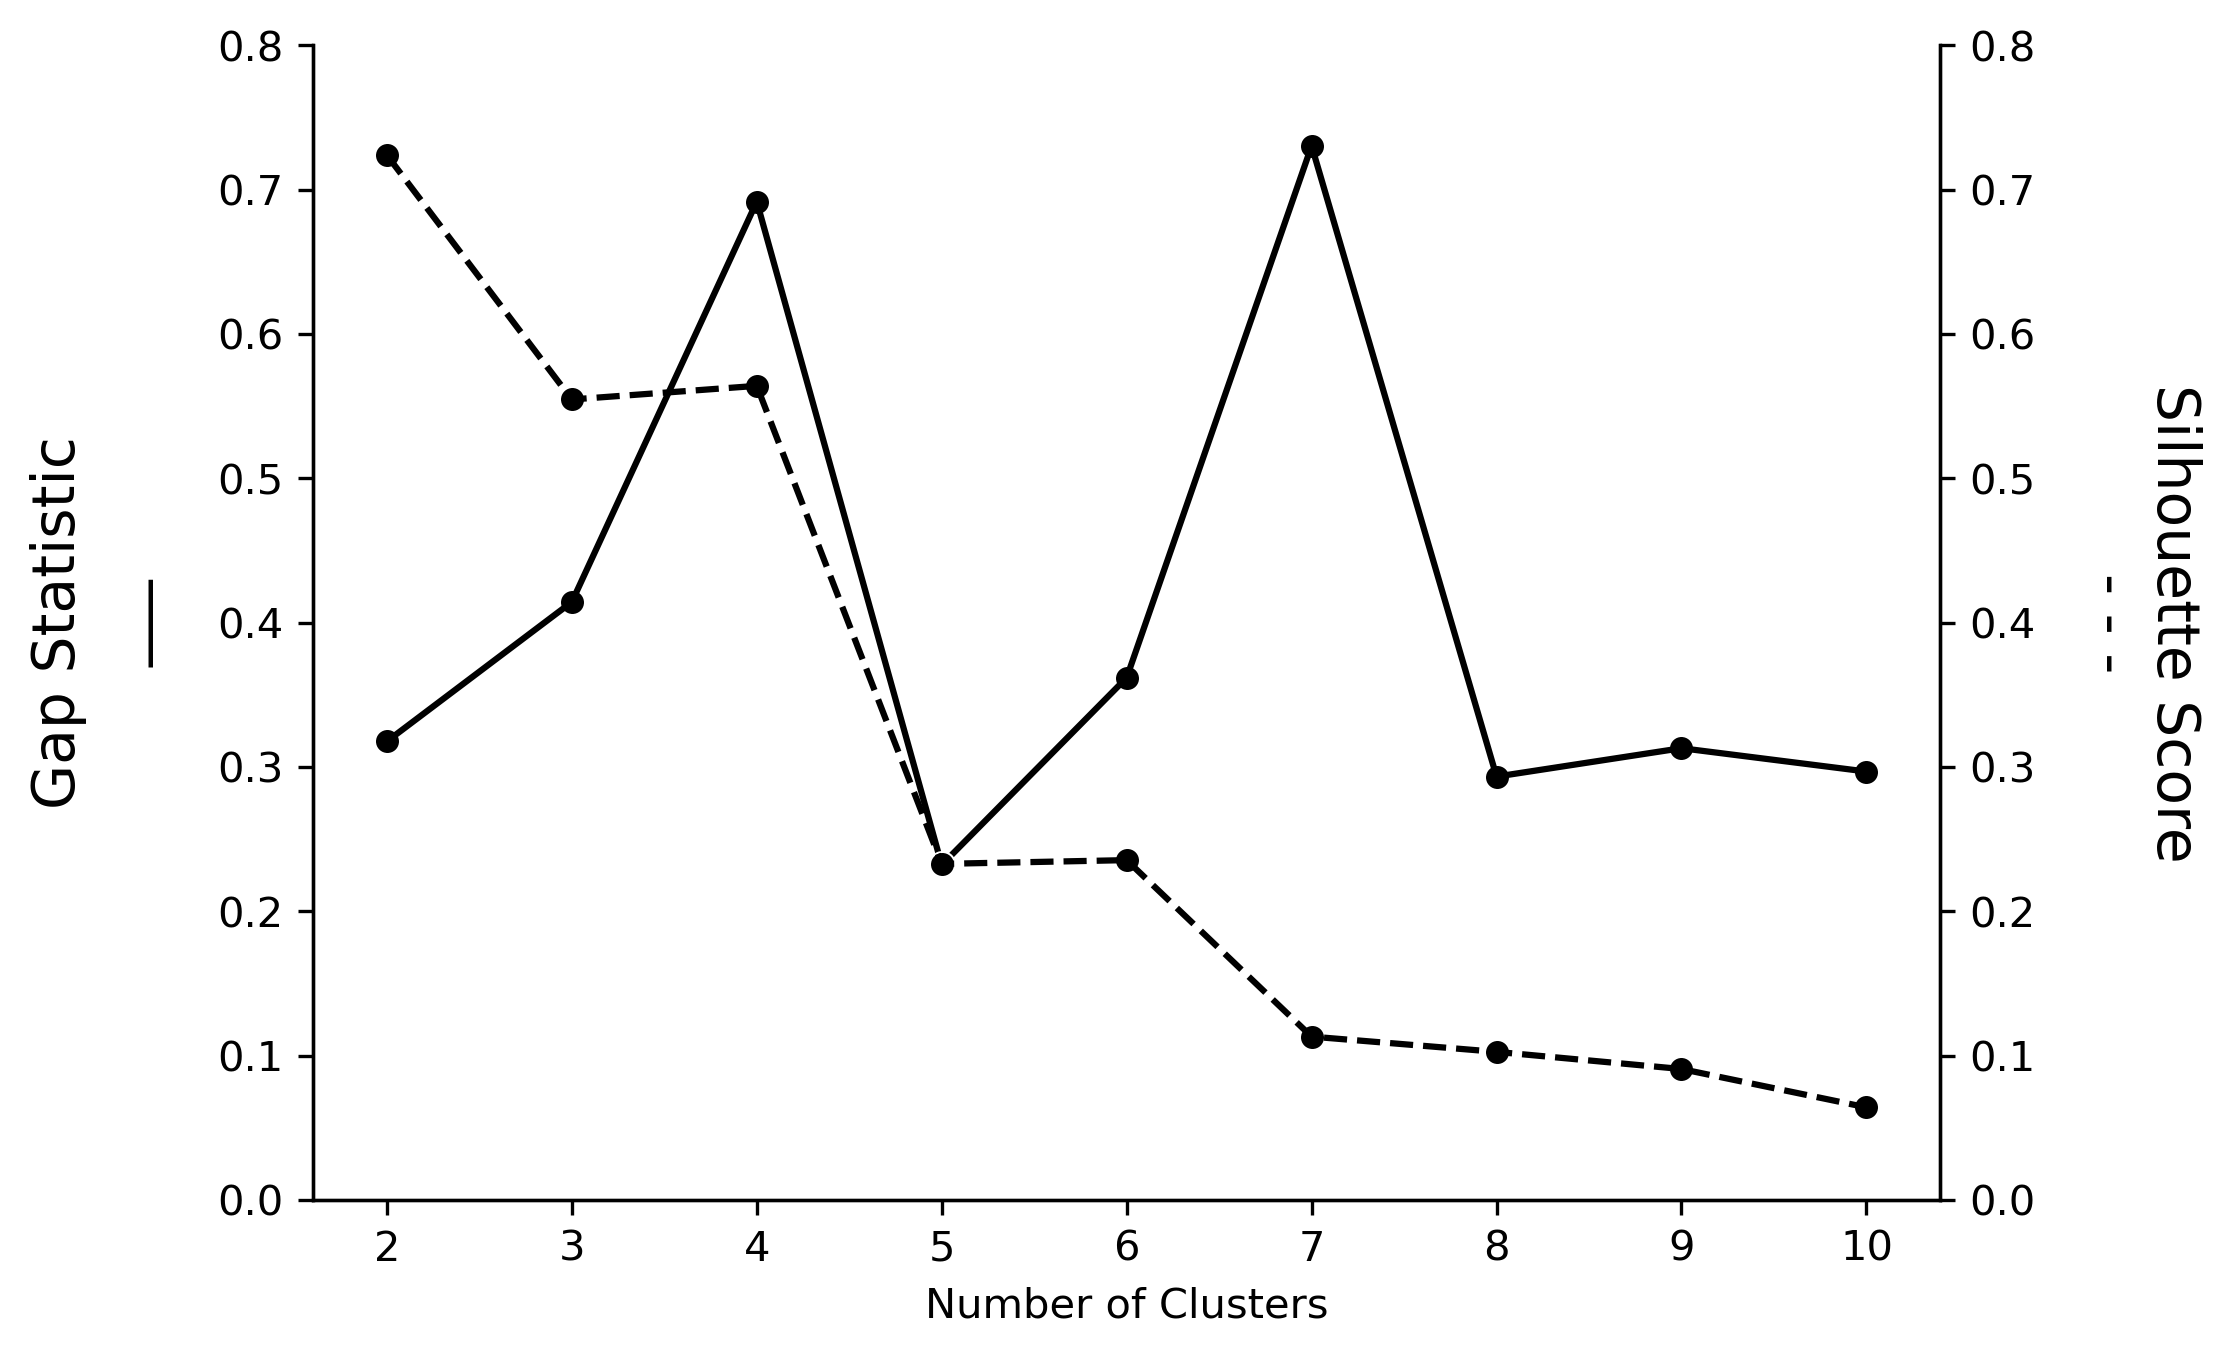

In [8]:
# Create reference data by randomly permuting column values
reference = abundance_heavy.apply(np.random.permutation, axis=0)

# Define function for calculating WCSS 
def calculate_wcss(X, labels):
    wcss = 0
    unique_clusters = np.unique(labels)
    for cluster in unique_clusters:
        cluster_points = X[labels == cluster]
        # Convert to array
        cluster_points = np.array(cluster_points)
        # Compute cluster centroid
        cluster_center = np.mean(cluster_points, axis=0)
        # Get Squared Euclidean distances
        wcss += np.sum((cluster_points - cluster_center) ** 2)
    return float(wcss)


## Spectral clustering

# Number of clusters to try on real data
range_n_clusters = [2,3,4,5,6,7,8,9,10]

# Make empty list to store results
results = []

X = abundance_heavy
for n_clusters in range_n_clusters:
    # Instantiate clustering model
    clusterer = SpectralClustering(n_clusters= n_clusters, random_state= 11, assign_labels='discretize')
    # Fit spectral clustering on the reference data
    reference_labels = clusterer.fit_predict(reference)
    wcss_reference = calculate_wcss(reference, reference_labels)
    # Fit spectral clustering on real data
    cluster_labels = clusterer.fit_predict(X)
    # Calculate Within-Cluster Sum of Squares
    wcss = calculate_wcss(X,cluster_labels)
    # Calculate gap statistic
    gap = np.log(wcss_reference) - np.log(wcss)
    # Calculate Silhouette Score
    silhouette = silhouette_score(X, cluster_labels)
    # Append to results
    results.append([n_clusters, gap, silhouette])
    
results = pd.DataFrame(results, columns = ['Number of Clusters','Gap Statistic','Silhouette Score'])

# Make figure
plt.figure(figsize= (7,5), dpi= 300)

# Plot gap statistic
p = sns.scatterplot(data= results, x= 'Number of Clusters', y= 'Gap Statistic', color= 'black')
sns.lineplot(data= results, x= 'Number of Clusters', y= 'Gap Statistic', color= 'black', ax= p)
p.set_ylabel("Gap Statistic\n___", labelpad= 15, fontsize= 14)

# Plot silhouette score
p2 = p.twinx()
sns.scatterplot(data= results, x= 'Number of Clusters', y= 'Silhouette Score', color= 'black', ax = p2)
sns.lineplot(data= results, x= 'Number of Clusters', y= 'Silhouette Score', color= 'black', ls= '--', ax= p2)
p2.set_ylabel("Silhouette Score\n- - -", rotation= -90, labelpad= 40, fontsize= 14)

# Tidy up
limits = (0,0.8)
p.set_ylim(limits)
p2.set_ylim(limits)
sns.despine(top= True, right= False)

# Save to file
plt.savefig("Figures/Cluster_support.png")

## Perform spectral clustering of MAGs based on abundance profiles using the optimum number of clusters

In [9]:
# Instantiate clustering algorithm
n_clusters = 4
clusterer = SpectralClustering(n_clusters= n_clusters, random_state=11, assign_labels='discretize')

# Cluster MAGs by abundance profile
abundance_heavy['Cluster'] = clusterer.fit_predict(abundance_heavy)+1
abundance_heavy.sort_values(by= 'Cluster', inplace= True)

## Rename clusters so they contain descending numbers of members
cluster_dict = dict(abundance_heavy['Cluster'].value_counts())
cluster_dict = dict((v,k) for k,v in cluster_dict.items())

# Get keys and sort
keys = sorted(cluster_dict.keys())[::-1]

# Match keys to clusters
clusters = [cluster_dict[key] for key in keys]

# Map to new cluster numbers
new_clusters = list(range(1,len(clusters)+1))
cluster_dict = dict(zip(clusters, new_clusters))

# Rename clusters
abundance_heavy['Cluster'] = abundance_heavy['Cluster'].apply(lambda x: cluster_dict[x])

# Sort data again
abundance_heavy.sort_values('Cluster', inplace= True)
abundance_heavy = abundance_heavy[['Cluster','lowT', 'highT', '2Weeks', '1Week', '2Days']]

# Export clustered data to file
abundance_heavy.to_csv("Clustering/Abundance_heavy_clustered.csv")

## Visualise abundance profiles of MAG clusters

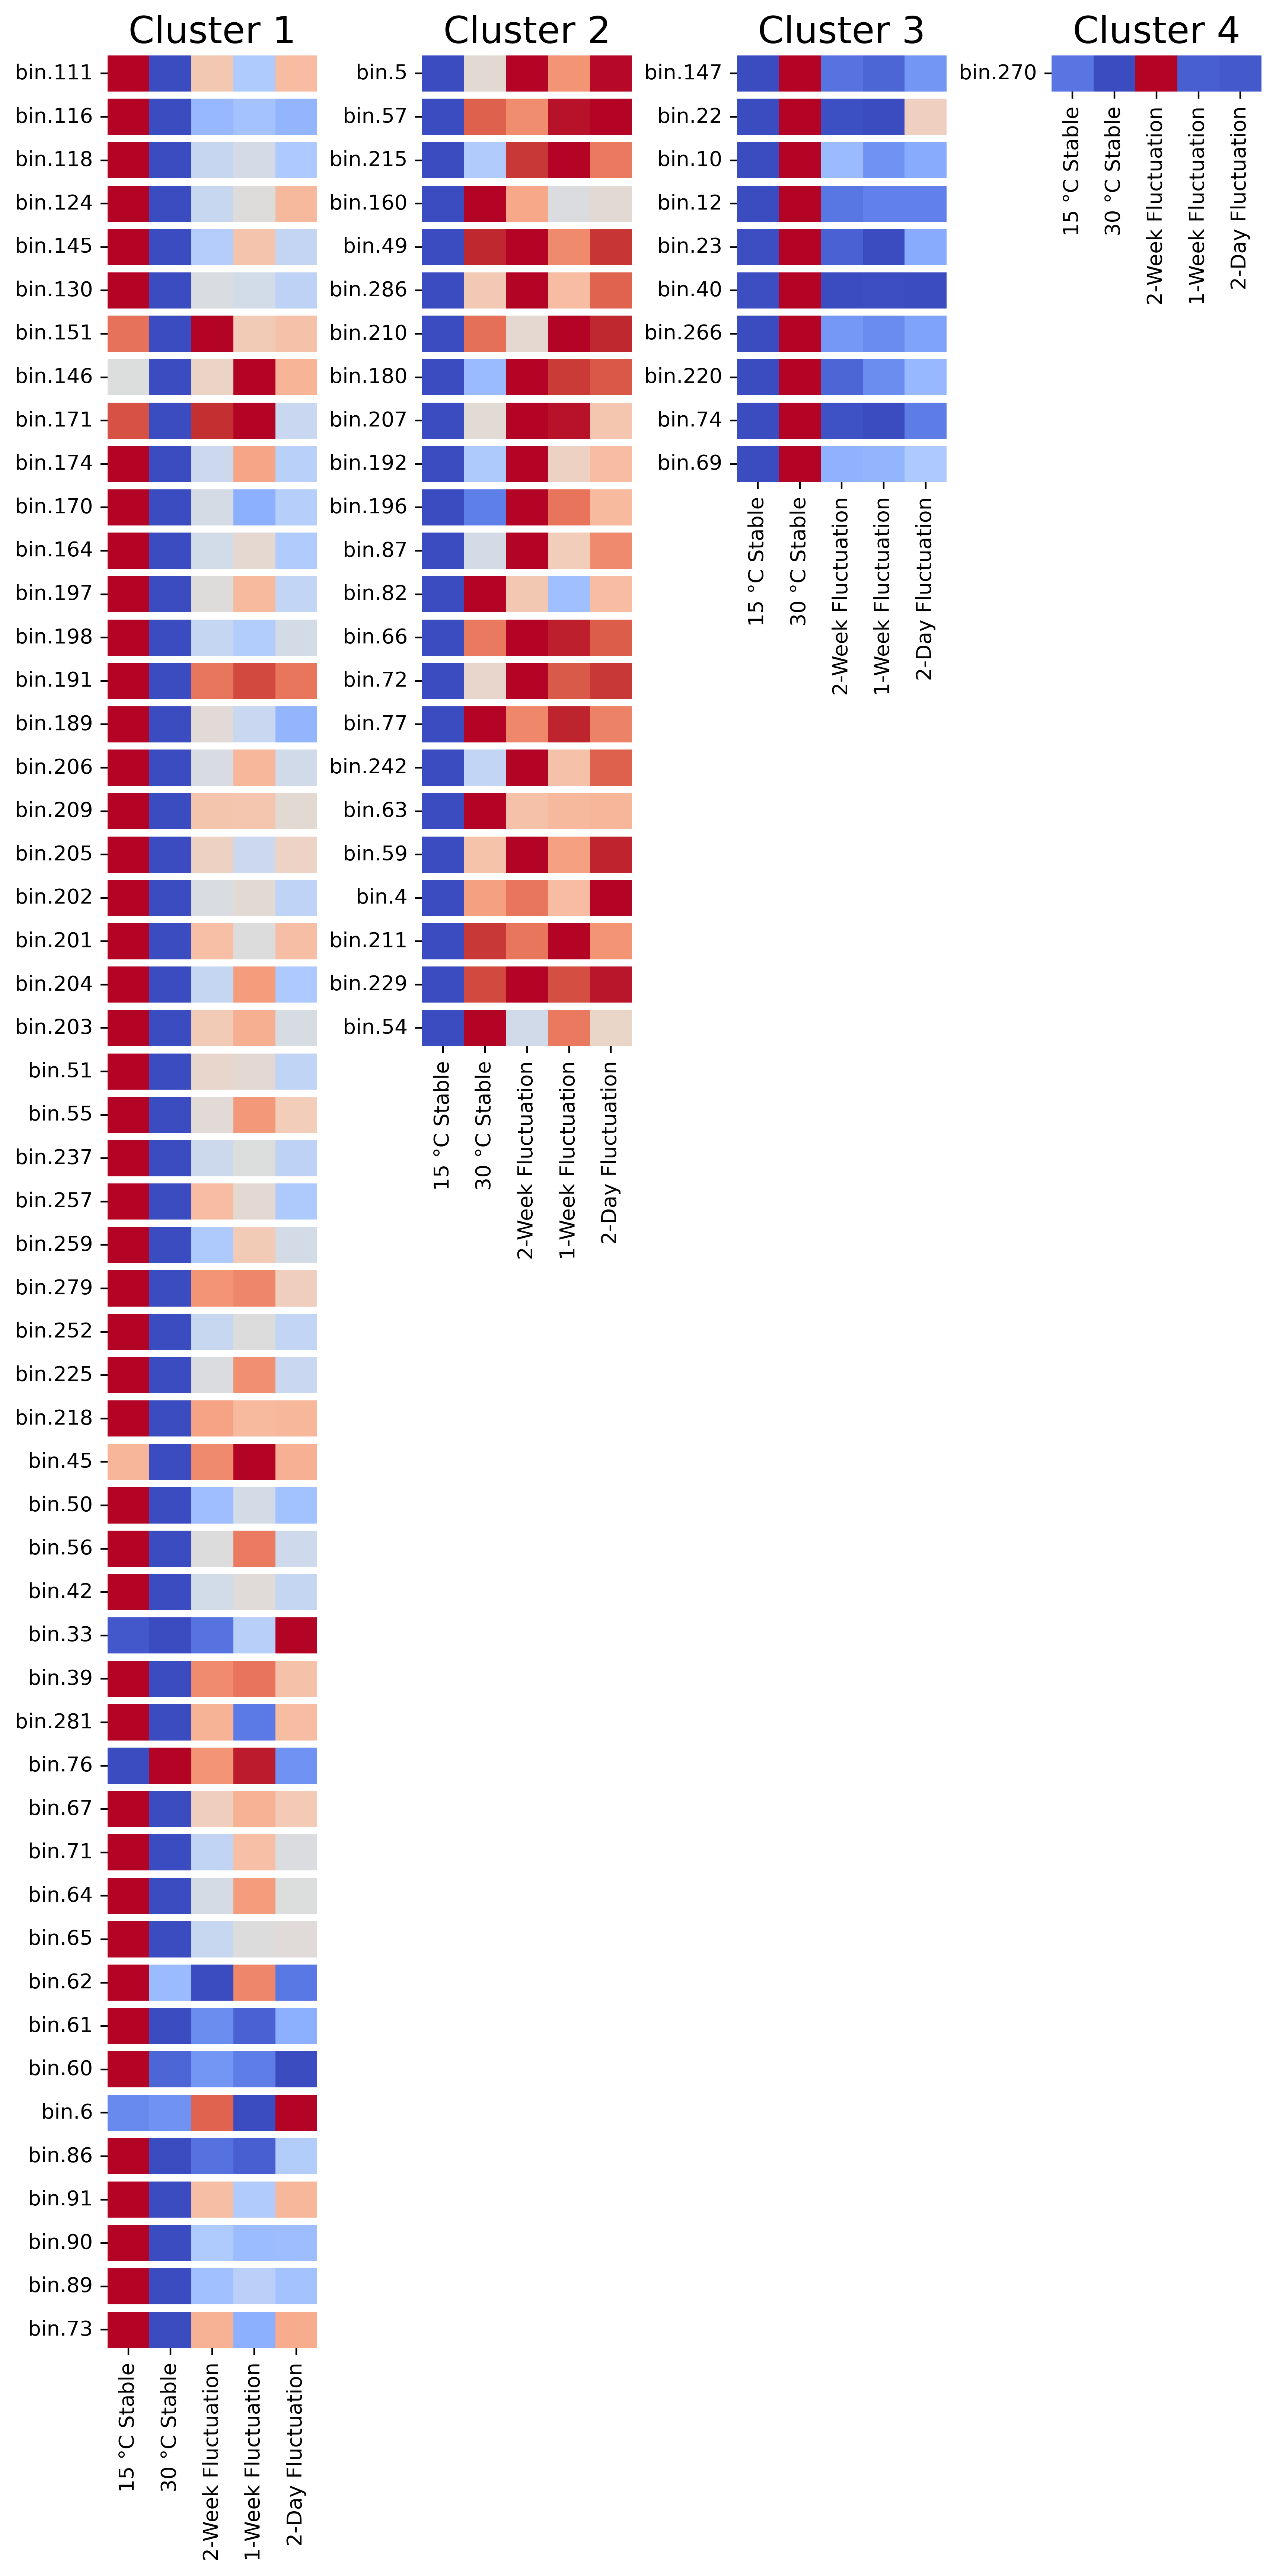

In [10]:
plot_data = abundance_heavy.copy()   

# Create treatment labels dictionary
labels = {'1Week': '1-Week Fluctuation',
          '2Days':'2-Day Fluctuation',
          '2Weeks':'2-Week Fluctuation',
          'highT':'30 °C Stable',
          'lowT':'15 °C Stable',
         }

# Rename columns for plotting
plot_data = plot_data.rename(columns= labels)

# Set up variables for automated column-wrapping of groups
group_sizes = list(plot_data['Cluster'].value_counts())
order = []
for group in group_sizes:
    order += (list(range(group)))

# Set number of rows and columns for subplots
n_rows= max(group_sizes)
n_cols= len(group_sizes)

# Set up plots
fig, axes = plt.subplots(nrows = n_rows, ncols= n_cols, figsize= (10,20), dpi= 400)
plt.subplots_adjust(wspace=0.5)


# Make heatmaps per MAG
for i in range(len(plot_data)):
    cluster = str(plot_data.iloc[i]['Cluster'].astype(int))
    column = int(cluster)-1 # Set column by cluster number
    ax = axes[order[i]][column]
    # Make heatmap
    p = sns.heatmap(plot_data.drop('Cluster', axis=1).iloc[i:i+1], cmap= 'coolwarm', ax= ax, cbar= False)
    try: # For automated labelling of x-axes
        order[i + 1]
        if order[i+1] == 0:
            ax.set_xticks(p.get_xticks(), labels= [item for item in p.get_xticklabels()], fontsize= 10)
        elif order[i+1] != 0:
            ax.set_xticks(ticks= [])
        else:
            pass
    except:
        ax.set_xticks(p.get_xticks(), labels= [item for item in p.get_xticklabels()], fontsize= 10)
        
    # Tidy up
    if order[i] == 0:
        ax.set_title(f"Cluster {cluster}", fontsize= 18)
    ax.set_yticklabels(p.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')        


#Hide any unused subplots
axes = np.array(axes).reshape(-1)
for ax in axes:
    if ax.has_data() == False:    
        fig.delaxes(ax)

# Save to file
plt.savefig("Figures/MAG_clustered_abundance_profiles_individual.png")

### Add cluster information to MAG data

In [11]:
# Add in cluster information
df_cluster = pd.merge(left=df[df.columns[:5]], right= abundance_heavy[['Cluster']].reset_index(), how= 'left', on= 'Genomic bins')

---
# Taxonomy

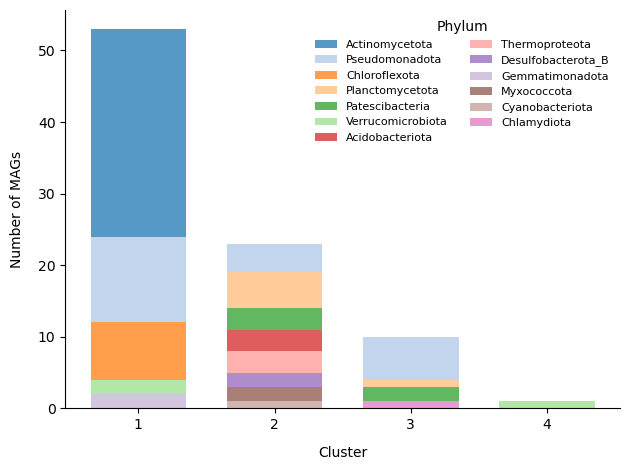

In [16]:
# Import taxonomy data
taxonomy = pd.read_csv("MAG_data/taxonomy.tsv", sep= '\t', header= None)
taxonomy.columns= ['Genomic bins','Domain','Phylum','Class','Order','Family','Genus','Species']
taxonomy.index= taxonomy['Genomic bins']
taxonomy.drop('Genomic bins', axis= 1, inplace= True)

# Add cluster information
taxonomy = pd.merge(left= taxonomy, right= df_cluster[['Genomic bins', 'Cluster']].drop_duplicates(),
                    how= 'left', left_index= True, right_on= 'Genomic bins')

# Restore original order
#taxonomy = taxonomy.loc[df_cluster.index]

# Export to file
taxonomy.to_csv("MAG_data/taxonomy_cluster.csv")

# Make plot of taxonomy by cluster
level= 'Phylum'
taxonomy[level] = taxonomy[level].apply(lambda x: x.split('__')[-1])
hue_order = list(taxonomy[level].value_counts().index) # hue order
fig = sns.histplot(data= taxonomy,
            x= 'Cluster', discrete= True, shrink= 0.7,
            hue= level, hue_order= hue_order, multiple= 'stack',
            palette= sns.color_palette('tab20',len(taxonomy[level].unique())),
            linewidth = 0, edgecolor= 'black')

# Tidy up 
sns.move_legend(fig, loc= 'upper right', bbox_to_anchor= (1, 1), fontsize= 8, ncol=2,
                frameon= False)
ticks = taxonomy['Cluster'].unique()
plt.xticks(ticks= ticks)
fig.set_ylabel('Number of MAGs', fontsize = 10, labelpad =10)
fig.set_xlabel('Cluster', fontsize= 10, labelpad= 10)
sns.despine()
plt.tight_layout()

# Save to file
plt.savefig("Figures/MAG_clustered_taxonomy.png");

# Genome Size by Cluster (with taxonomy)

In [19]:
genome_size = pd.read_csv("MAG_data/genome_size_cluster.csv")
genome_size.groupby('Cluster')['Genome size'].mean()

Cluster
1    3.659944e+06
2    5.272763e+06
3    2.953819e+06
4    3.072376e+06
Name: Genome size, dtype: float64

#### Kruskal-Wallis test

In [20]:
%%R

# Import data
df = read.csv("MAG_data/genome_size_cluster.csv")

# Perform Kruskal-Wallis test
# as genome size is not normally distributed within groups
kruskal.test(formula = Genome.size ~ Cluster, data= df)


	Kruskal-Wallis rank sum test

data:  Genome.size by Cluster
Kruskal-Wallis chi-squared = 9.8287, df = 3, p-value = 0.02008



#### Dunn's test

In [21]:
%%R

# Import data
df = read.csv("MAG_data/genome_size_cluster.csv")

dunn_result = dunn.test(df$Genome.size, df$Cluster, method= "bh")

comparisons = dunn_result$comparisons
p_values = dunn_result$P.adjusted

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 9.8287, df = 3, p-value = 0.02


                           Comparison of x by group                            
                             (Benjamini-Hochberg)                              
Col Mean-|
Row Mean |          1          2          3
---------+---------------------------------
       2 |  -2.046409
         |     0.0611
         |
       3 |   1.829055   3.013792
         |     0.0674    0.0077*
         |
       4 |   0.373719   0.869500  -0.241586
         |     0.4252     0.2884     0.4046

alpha = 0.05
Reject Ho if p <= alpha/2


In [22]:
comparisons = list(ro.r("comparisons"))
p_values = list(ro.r("p_values"))
p_values = [f"{value:.3f}" for value in p_values]
p_values = dict(zip(comparisons,p_values))

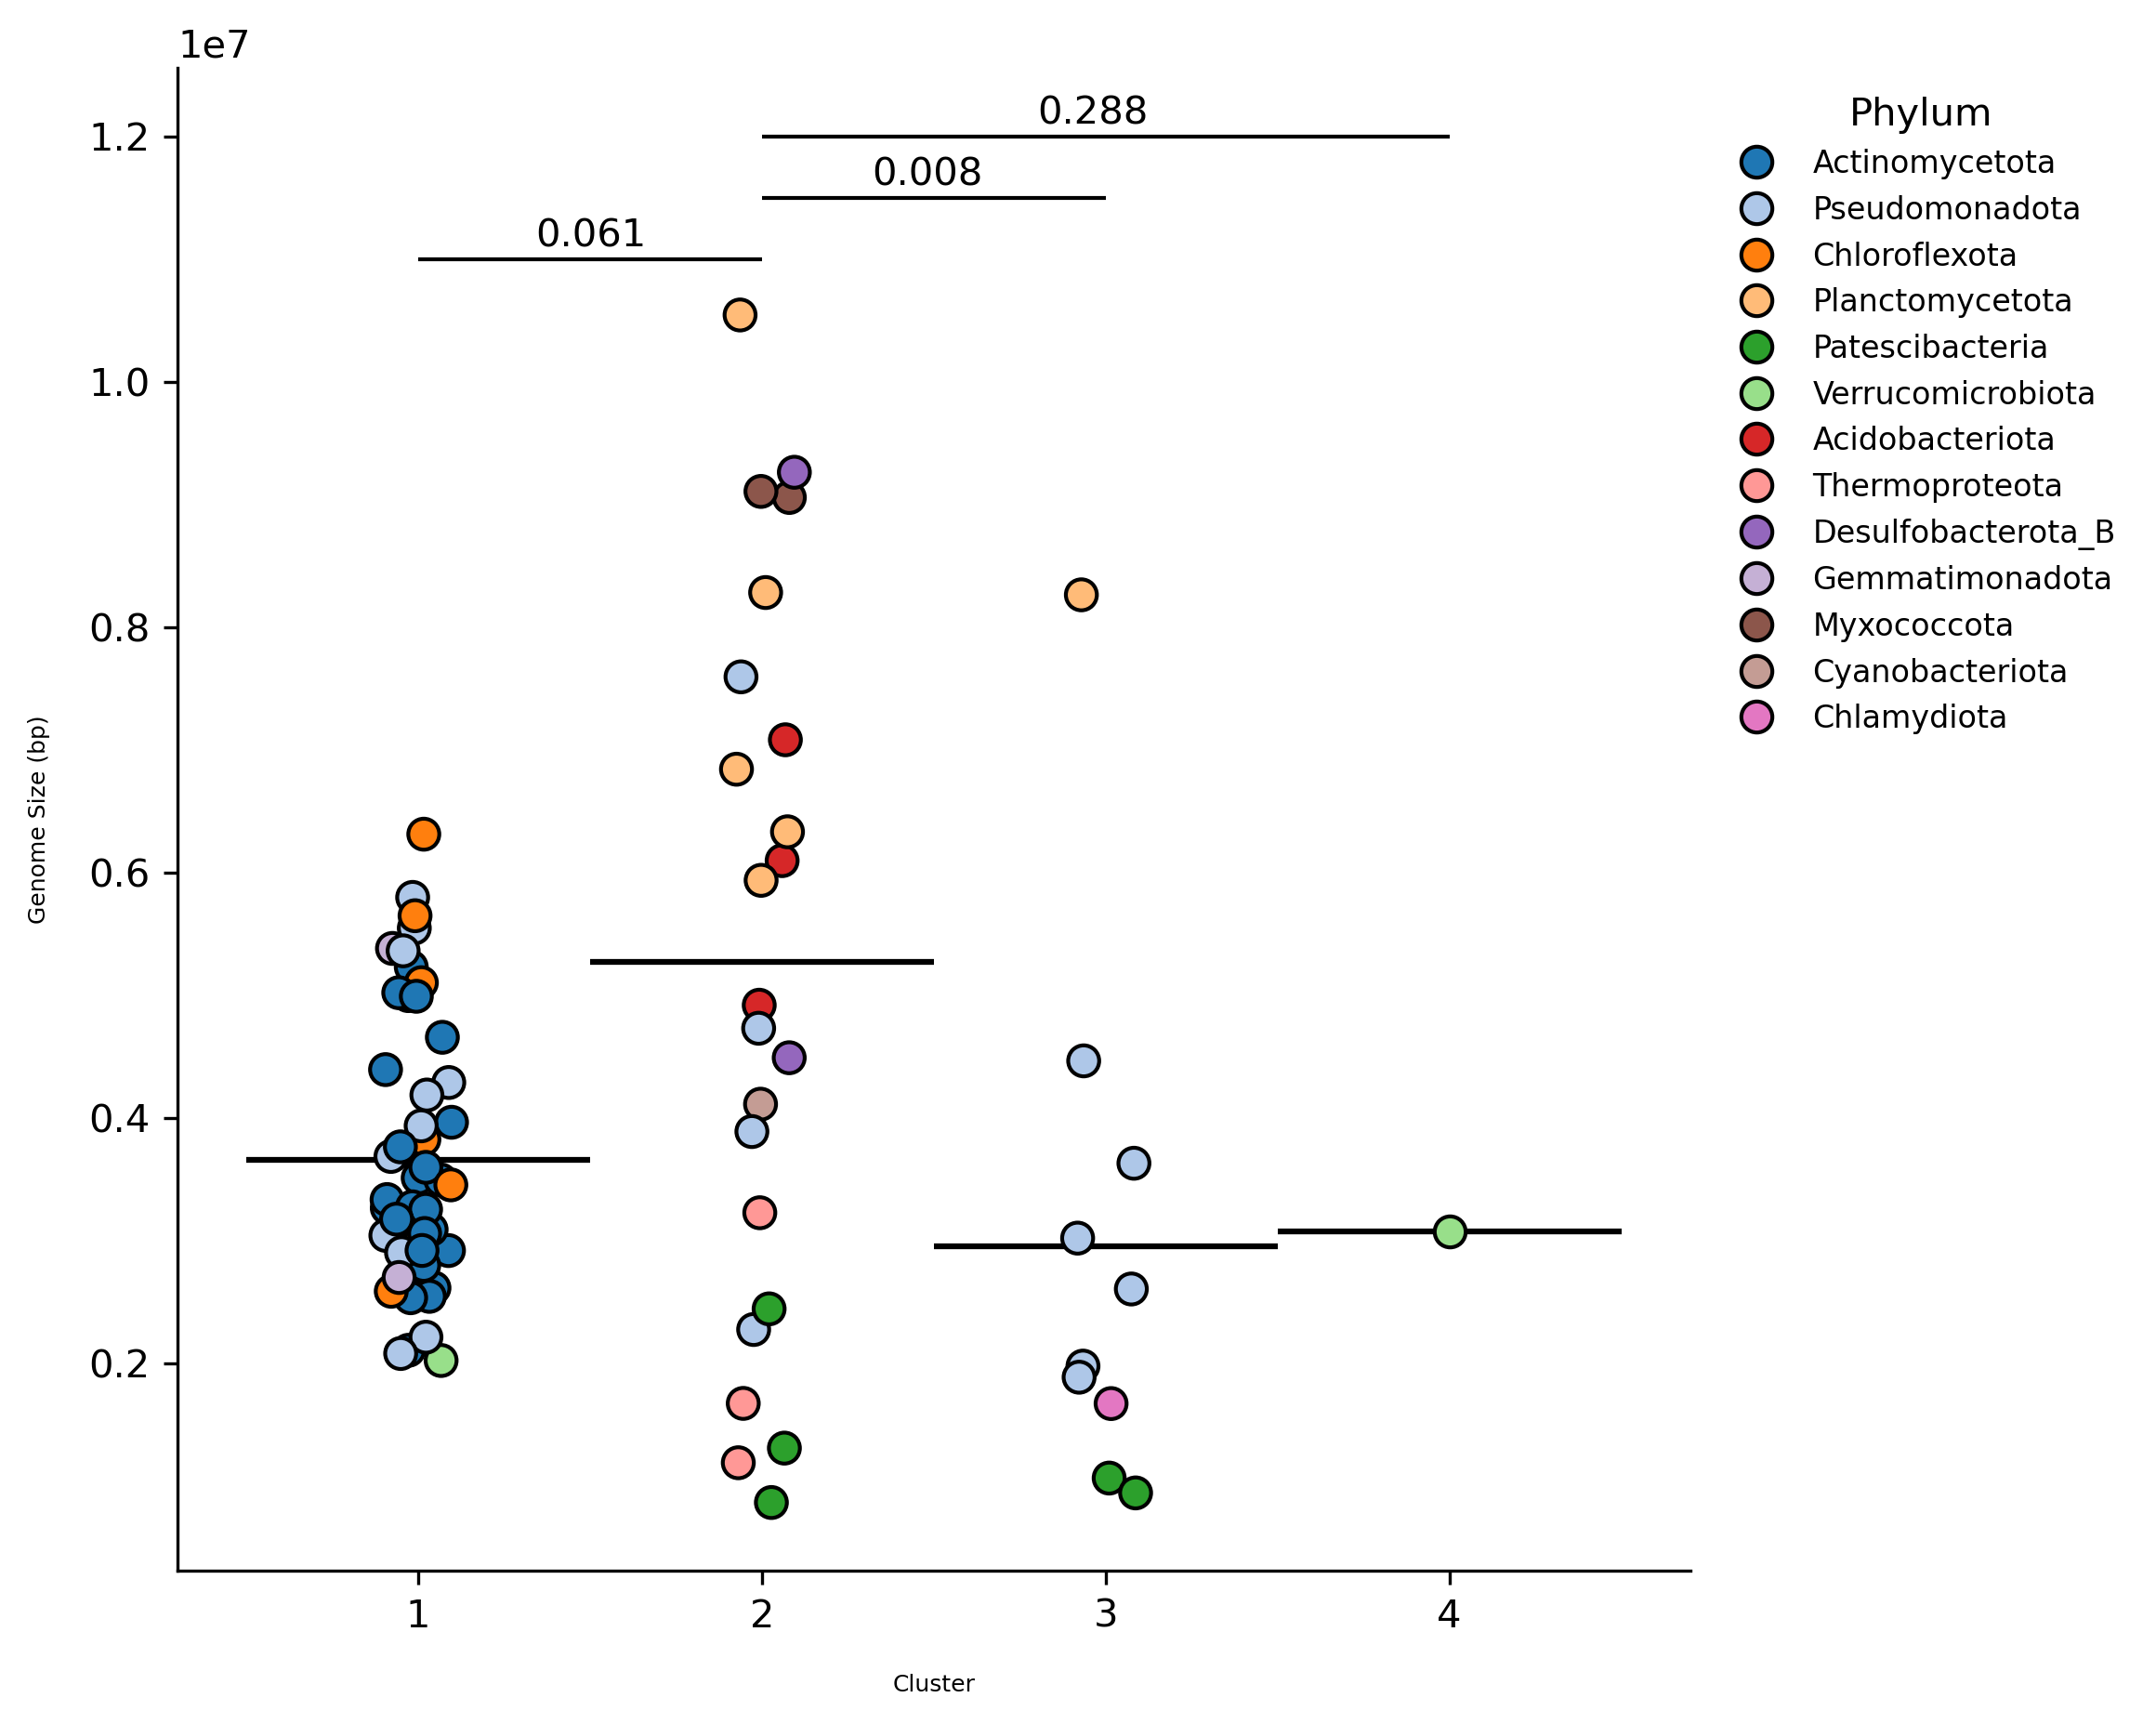

In [23]:
# Import genome size data
genome_size = pd.read_csv("MAG_data/genome_size.csv")

# add cluster information
genome_size = pd.merge(left = genome_size, right= df_cluster[['Genomic bins', 'Cluster']].drop_duplicates(), how= 'inner', on= 'Genomic bins')

# export to file for KW testing
genome_size.to_csv("MAG_data/genome_size_cluster.csv", index= False)

# add taxonomy information
level = 'Phylum'
genome_size = pd.merge(left= genome_size, right= taxonomy.reset_index()[['Genomic bins', level]], how= 'left', on= 'Genomic bins')


# Plot GC content by cluster
plt.figure(figsize= (7,7), dpi= 300)
fig = sns.stripplot(data= genome_size, x= 'Cluster', y= 'Genome size', alpha= 1, hue= level, hue_order= hue_order,
                    palette = 'tab20', native_scale= True, s= 8, linewidth= 1, edgecolor= 'black')

# Add lines for mean
## cluster 1
cluster = 1
y = genome_size.query(f"Cluster == {cluster}")['Genome size'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')
## cluster 2
cluster = 2
y = genome_size.query(f"Cluster == {cluster}")['Genome size'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')
## cluster 3
cluster = 3
y = genome_size.query(f"Cluster == {cluster}")['Genome size'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')
## cluster 4
cluster = 4
y = genome_size.query(f"Cluster == {cluster}")['Genome size'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')


# Add lines for comparisons (manually)
## 1 vs 2
plt.hlines(xmin= 1, xmax= 2, y= 1.1e7, color= 'Black', linewidth= 1)
plt.text(x= 1.34, y= 1.11e7, s= f"{p_values['1 - 2']}")
## 2 vs 3
plt.hlines(xmin= 2, xmax= 3, y= 1.15e7, color= 'Black', linewidth= 1)
plt.text(x= 2.32, y= 1.16e7, s= f"{p_values['2 - 3']}")
## 2 vs 4
plt.hlines(xmin= 2, xmax= 4, y= 1.2e7, color= 'Black', linewidth= 1)
plt.text(x= 2.8, y= 1.21e7, s= f"{p_values['2 - 4']}")


# Tidy up
sns.move_legend(fig, loc= 'upper right', bbox_to_anchor= (1.3, 1), fontsize= 8, ncol=1,
                frameon= False)
plt.ylabel('Genome Size (bp)', fontsize= 6, labelpad =10)
plt.xlabel('Cluster', fontsize= 6, labelpad =10)
ticks = genome_size['Cluster'].unique()
plt.xticks(ticks= ticks)
sns.despine()

# Save to file
plt.savefig("Figures/MAG_clustered_genome_size.png");

# GC Content by Cluster (with Taxonomy)

In [24]:
GC = pd.read_csv("MAG_data/GC_cluster.csv")
GC.groupby('Cluster')['GC'].mean()

Cluster
1    67.761509
2    56.334783
3    57.291000
4    58.220000
Name: GC, dtype: float64

#### Kruskal-Wallis test

In [25]:
%%R

# Import data
df = read.csv("MAG_data/GC_cluster.csv")

# Perform Kruskal-Wallis test
# as GC content is not normally distributed within groups
kruskal.test(formula = GC ~ Cluster, data= df)


	Kruskal-Wallis rank sum test

data:  GC by Cluster
Kruskal-Wallis chi-squared = 39.933, df = 3, p-value = 1.101e-08



#### Dunn's test

In [26]:
%%R

# Import data
df = read.csv("MAG_data/GC_cluster.csv")

dunn_result = dunn.test(df$GC, df$Cluster, method= "bh")

comparisons = dunn_result$comparisons
p_values = dunn_result$P.adjusted

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 39.9327, df = 3, p-value = 0


                           Comparison of x by group                            
                             (Benjamini-Hochberg)                              
Col Mean-|
Row Mean |          1          2          3
---------+---------------------------------
       2 |   5.584395
         |    0.0000*
         |
       3 |   3.927022  -0.106792
         |    0.0001*     0.4575
         |
       4 |   1.557057   0.173564   0.207615
         |     0.1195     0.5173     0.6266

alpha = 0.05
Reject Ho if p <= alpha/2


In [27]:
comparisons = list(ro.r("comparisons"))
p_values = list(ro.r("p_values"))
p_values = [f"{value:.3f}" for value in p_values]
p_values = dict(zip(comparisons,p_values))

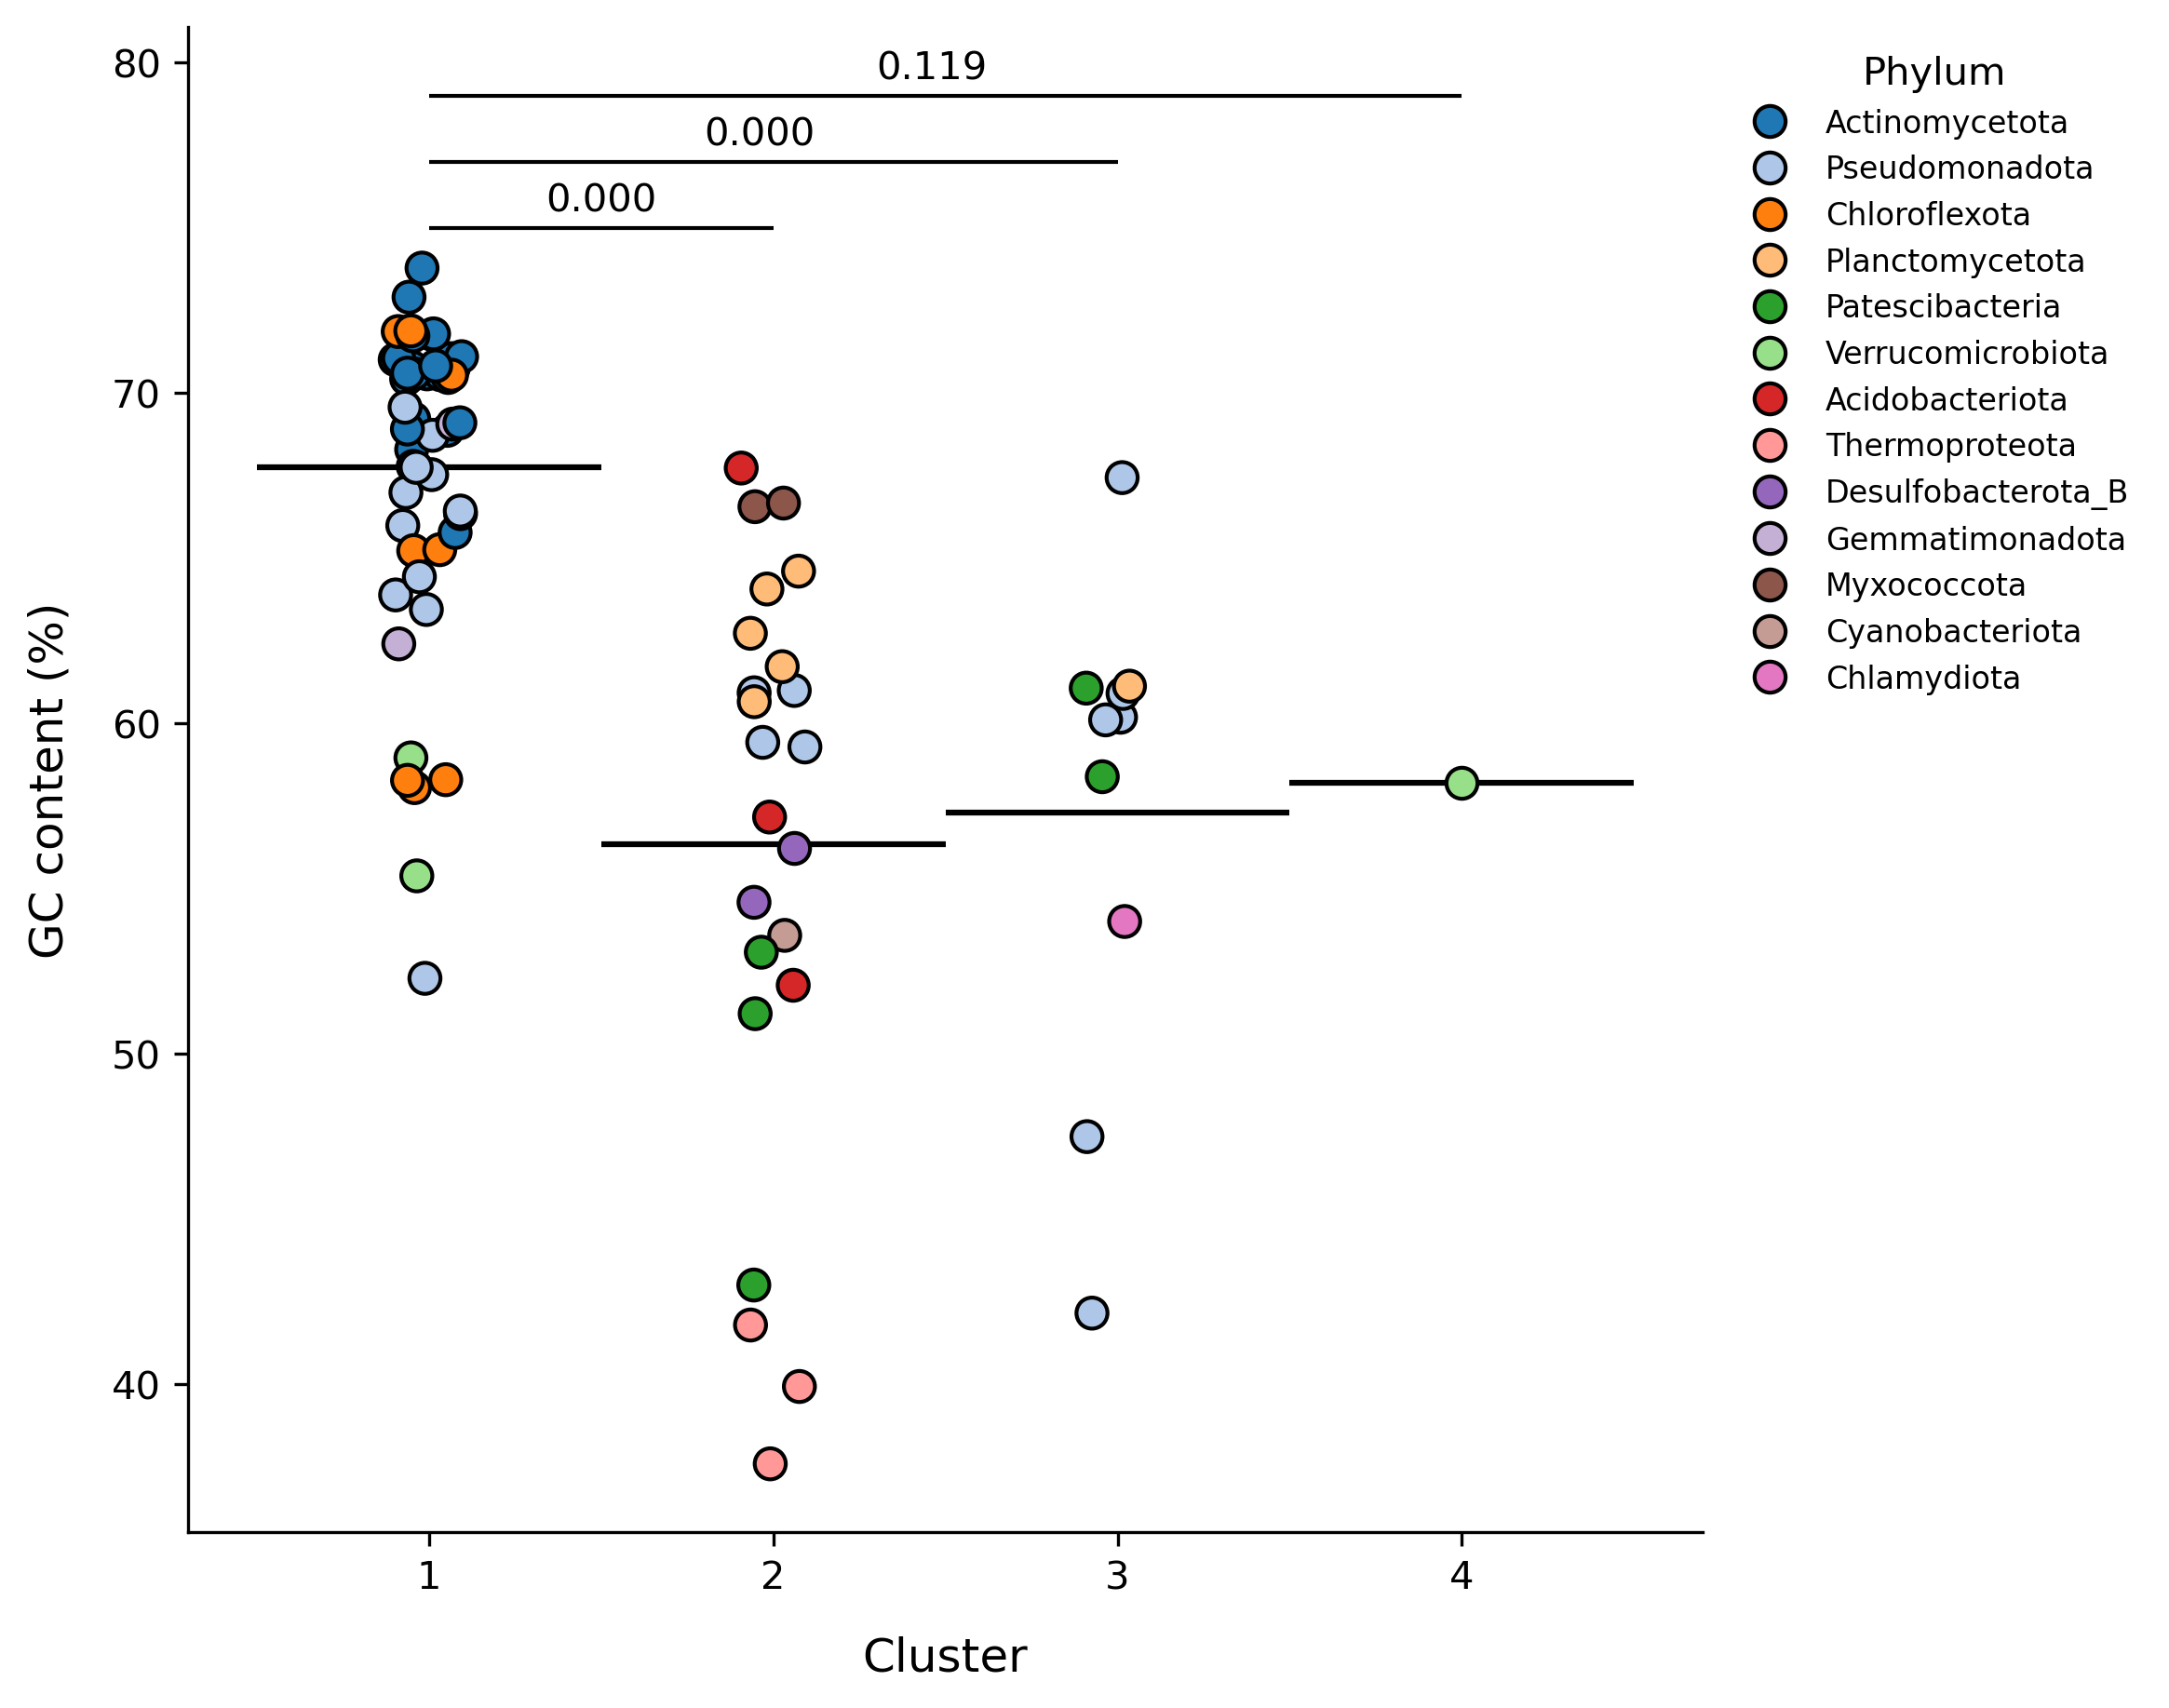

In [28]:
level = 'Phylum'

# Import GC content data
GC = pd.read_csv("MAG_data/gc-content.csv")

# add cluster information
GC = pd.merge(left = GC, right= df_cluster[['Genomic bins', 'Cluster']].drop_duplicates()
              , how= 'left', on= 'Genomic bins')

# export to file for KW testing
GC.to_csv("MAG_data/GC_cluster.csv", index= False)

# add taxonomy information
GC = pd.merge(left= GC, right= taxonomy.reset_index()[['Genomic bins', level]], how= 'left', on= 'Genomic bins')


# Plot GC content by cluster
fig = plt.figure(figsize= (7,7), dpi= 300)
fig = sns.stripplot(data= GC, x= 'Cluster', y= 'GC', hue= level, hue_order= hue_order,
                    palette = 'tab20', alpha= 1, native_scale= True, s= 8,
                    linewidth= 1, edgecolor= 'black')


# Add lines for mean
## cluster 1
cluster = 1
y = GC.query(f"Cluster == {cluster}")['GC'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')
## cluster 2
cluster = 2
y = GC.query(f"Cluster == {cluster}")['GC'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')
## cluster 3
cluster = 3
y = GC.query(f"Cluster == {cluster}")['GC'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')
## cluster 4
cluster = 4
y = GC.query(f"Cluster == {cluster}")['GC'].mean()
plt.hlines(xmin= cluster-0.5, xmax= cluster+0.5, y= y, color= 'Black')

# Add lines for comparisons (manually)
## 1 vs 2
plt.hlines(xmin= 1, xmax= 2, y= 75, color= 'Black', linewidth= 1)
plt.text(x= 1.34, y= 75.5, s= f"{p_values['1 - 2']}")
## 1 vs 3
plt.hlines(xmin= 1, xmax= 3, y= 77, color= 'Black', linewidth= 1)
plt.text(x= 1.8, y= 77.5, s= f"{p_values['1 - 3']}")
## 1 vs 4
plt.hlines(xmin= 1, xmax= 4, y= 79, color= 'Black', linewidth= 1)
plt.text(x= 2.3, y= 79.5, s= f"{p_values['1 - 4']}")


# Tidy up
sns.move_legend(fig, loc= 'upper right', bbox_to_anchor= (1.3, 1), fontsize= 8, ncol=1,
                frameon= False)
plt.ylabel('GC content (%)', fontsize= 12, labelpad =10)
plt.xlabel('Cluster', fontsize= 12, labelpad =10)
ticks = GC['Cluster'].unique()
plt.xticks(ticks= ticks)
sns.despine()

# Save to file
plt.savefig("Figures/MAG_clustered_GC_content_with_taxonomy.png");

---
# COG Categories by MAG Cluster

In [23]:
# Import COG data
COG = pd.read_csv("MAG_data/normalised_cog_category_proportions.csv", index_col= 0).reset_index(names= 'Genomic bins')

# Add cluster information
COG = pd.merge(left = COG, right= df_cluster[['Genomic bins', 'Cluster']].drop_duplicates(), how= 'left', on= 'Genomic bins')

# Group by MAG cluster
COG_by_cluster = COG.drop('Genomic bins', axis= 1).groupby('Cluster').mean().reset_index()

## Sparse Partial Least Squares Discriminant Analysis (sPLS-DA)

In [24]:
!mkdir -p sPLS-DA

In [25]:
# Select data
data = COG.drop(['Genomic bins', 'Cluster'], axis=1).copy()

# Drop columns with all 0 values
data = data.loc[:, (data != 0).any(axis=0)]

# Standard scale each feature so they contribute equally to the model
scaler = StandardScaler()
data = pd.DataFrame(scaler.fit_transform(data), columns= data.columns)

# Reattach cluster information
data['Cluster'] = COG['Cluster']
# Reattach bin identifiers
data['Genomic bins'] = COG['Genomic bins']

# Export to file
data.to_csv("sPLS-DA/sPLS-DA_input.csv", index= False)


### Cross validation for number of features to retain for each component

In [26]:
%%R

set.seed(11)

# Load in data
data = read.csv("sPLS-DA/sPLS-DA_input.csv")

# Remove only Cluster 4 MAG (interferes with train / test splits)
data = subset(data, Cluster != 4)

# Remove Cluster and Genomic bins columns
Cluster = data$Cluster
genomicBins = data$Genomic.bins
data$Cluster = NULL
data$Genomic.bins = NULL

X = data
y = Cluster

# Set list of values to test for number of variables to keep
keepX.values = c(1,2,3,4,5,6)

tuning = tune.splsda(as.data.frame(X),as.factor(y),
                                ncomp= 3,
                                validation= "Mfold",
                                folds= 5,
                                scale= FALSE,
                                test.keepX = keepX.values,
                                dist= "max.dist",
                                measure= "BER",
                                nrepeat= 100,
                                progressBar= FALSE)

### sPLS-DA with chosen number of features per component

In [27]:
%%R

set.seed(11)

# Import library
library(mixOmics)

# Load in data
data = read.csv("sPLS-DA/sPLS-DA_input.csv")

# Remove Cluster and Genomic bins columns
Cluster = data$Cluster
genomicBins = data$Genomic.bins
data$Cluster = NULL
data$Genomic.bins = NULL

X = data
y = Cluster

# Train model
result = splsda(X,y, ncomp=3, scale= FALSE, max.iter=100, keepX= tuning$choice.keepX)

# Save to file values for Genomic bins in the transformed feature space
write.csv(data.frame(result$variates$X), "sPLS-DA/sPLS-DA_output.csv")

# Save to file loadings for each feature in each component
write.csv(data.frame(result$loadings$X), "sPLS-DA/sPLS-DA_loadings.csv")

### Evaluate model performance

In [28]:
%%R

set.seed(11)

# Load in data
data = read.csv("sPLS-DA/sPLS-DA_input.csv")

# Remove only Cluster 4 MAG (interferes with train / test splits)
data = subset(data, Cluster != 4)

# Remove Cluster and Genomic bins columns
Cluster = data$Cluster
genomicBins = data$Genomic.bins
data$Cluster = NULL
data$Genomic.bins = NULL

X = data
y = Cluster

# Train model
trained_model = splsda(X,y, ncomp=3, scale= FALSE, max.iter=100, keepX= tuning$choice.keepX)

performance <- perf(trained_model, validation = "Mfold", folds=5, progressBar = FALSE, nrepeat = 100, measure= "BER", dist= "centroids.dist")

#### Get balanced overall error rate

In [29]:
# Get balanced error rate
BER = ro.r("performance$error.rate$BER")

# Story accuracy
accuracy = np.round((1 - BER[-1]) *100,1)

# Calculate classification accuracy with all components
print(f"Classification accuracy with one component: {np.round((1 - BER[0]) *100,1)}%")
print(f"Classification accuracy with two components: {np.round((1 - BER[1]) *100,1)}%")
print(f"Classification accuracy with all components: {np.round((1 - BER[-1]) *100,1)}%")

Classification accuracy with one component: 50.3%
Classification accuracy with two components: 63.0%
Classification accuracy with all components: 66.2%


#### Get per class error rate

In [30]:
err_c1, err_c2, err_c3 = list(ro.r("data.frame(performance$error.rate.class)$centroids.dist.comp.3"))

print(f"""
Classification accuracy with all components for
Cluster 1: {np.round((1 - err_c1)*100,1)}%
Cluster 2: {np.round((1 - err_c2)*100,1)}%
Cluster 2: {np.round((1 - err_c3)*100,1)}%
""")


Classification accuracy with all components for
Cluster 1: 84.3%
Cluster 2: 48.7%
Cluster 2: 65.5%



#### Extract feature selection frequency

In [31]:
# Component 1 features
stable_features = ro.r("performance$features$stable$'comp 1'")
stable_names = ro.r("names(performance$features$stable$'comp 1')")
comp_1 = pd.DataFrame(stable_features,index= stable_names, columns= ['Component 1'])

# Component 2 features
stable_features = ro.r("performance$features$stable$'comp 2'")
stable_names = ro.r("names(performance$features$stable$'comp 2')")
comp_2 = pd.DataFrame(stable_features,index= stable_names, columns= ['Component 2'])

# Component 3 features
stable_features = ro.r("performance$features$stable$'comp 3'")
stable_names = ro.r("names(performance$features$stable$'comp 3')")
comp_3 = pd.DataFrame(stable_features,index= stable_names, columns= ['Component 3'])

stable_features = pd.merge(left= comp_1,right= comp_2, how= 'outer', left_index=True, right_index=True).fillna(0)
stable_features = pd.merge(left= stable_features,right= comp_3, how= 'outer', left_index=True, right_index=True).fillna(0)

stable_features.to_csv("sPLS-DA/sPLS-DA_Stable_features.csv", index= True)

### Get values for each MAG in transformed space and plot ordination

#### Import and format data

In [32]:
sPLS_DA = pd.read_csv("sPLS-DA/sPLS-DA_output.csv", index_col=0).reset_index(drop= True)

# Reattach MAG names and clusters
sPLS_DA['Cluster'] = data['Cluster'].astype(int)
sPLS_DA['Genomic bins'] = data['Genomic bins']

#### Plot all MAGs and cluster centroids

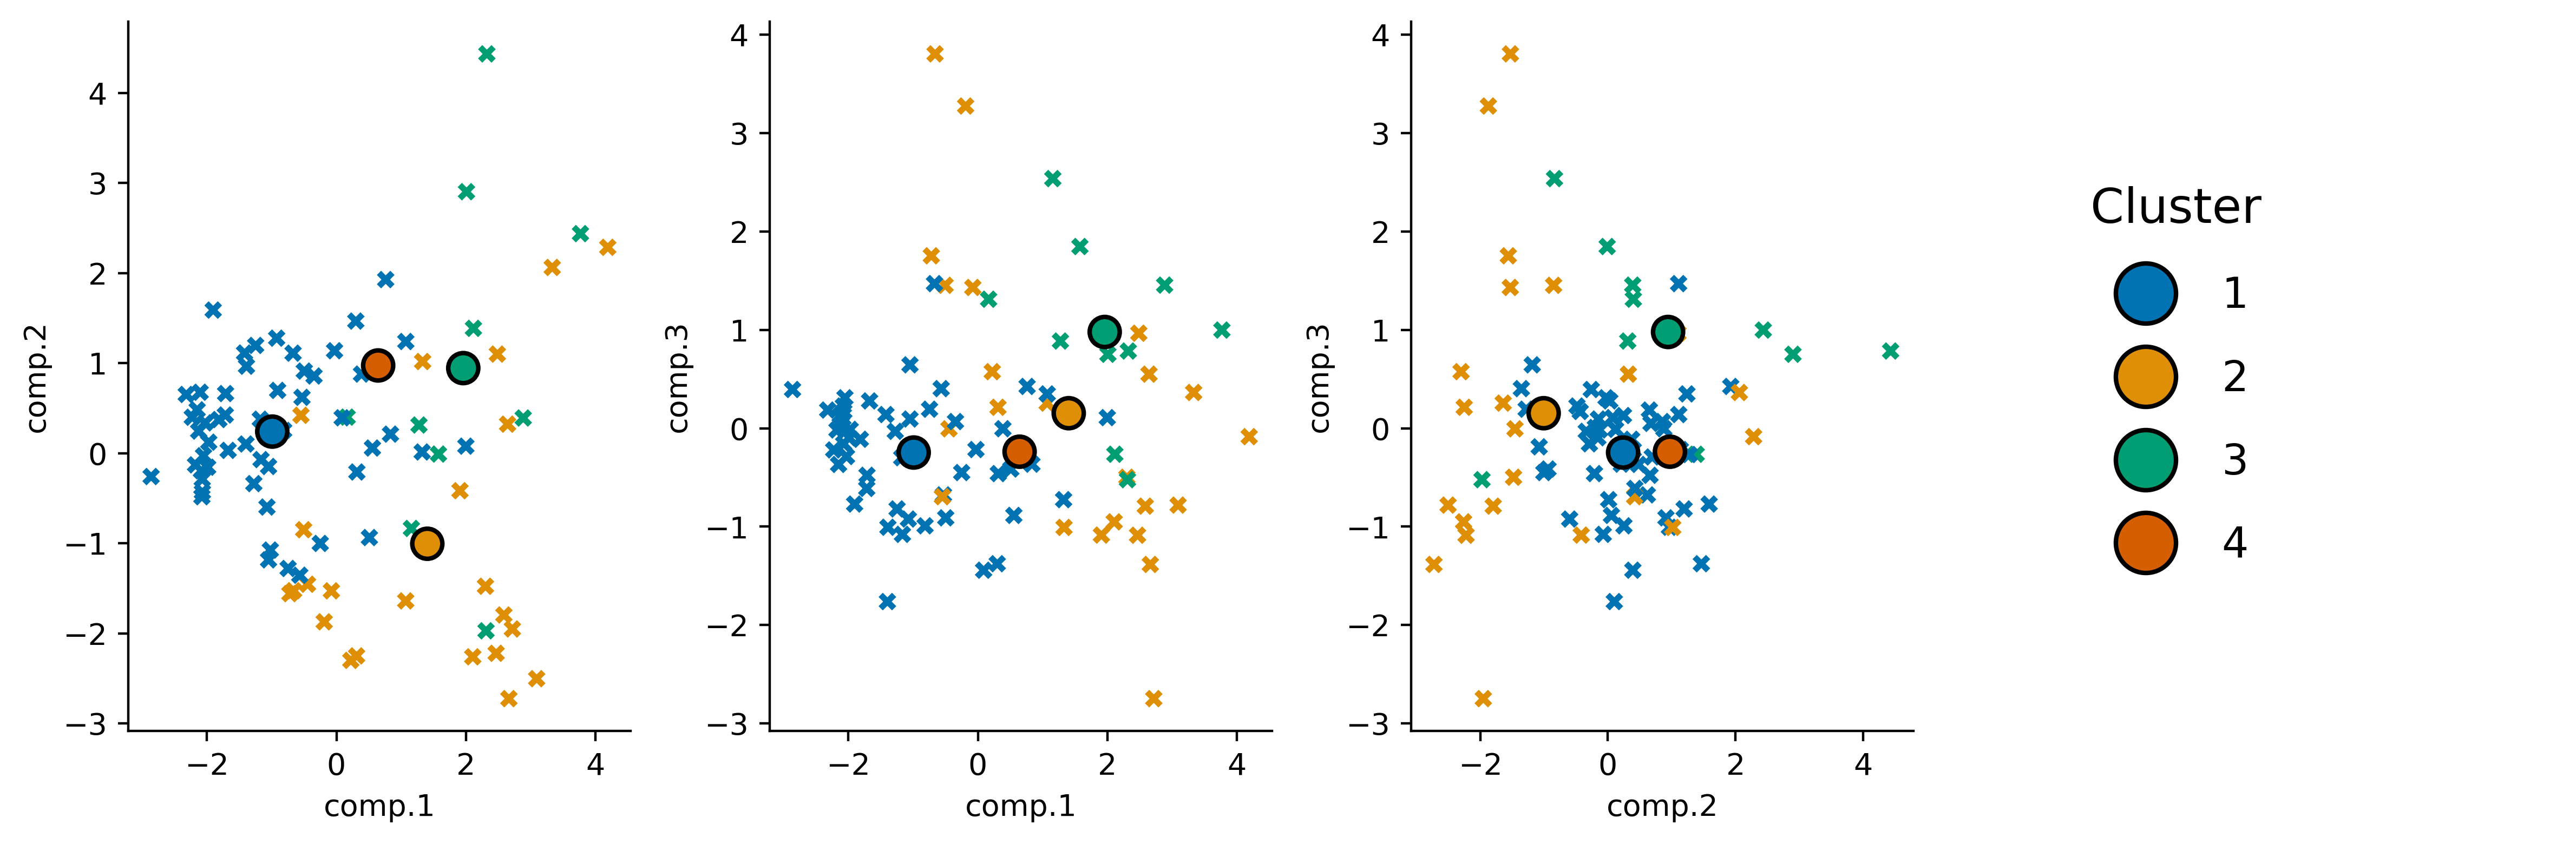

In [33]:
# Horizontal
fig, axes = plt.subplots(ncols= 4, nrows= 1, figsize= (12,4), dpi= 400)

# # Vertical
# fig, axes = plt.subplots(ncols= 1, nrows= 4, figsize= (4,12), dpi= 300)

axes = axes.flatten()

# Make custom colour palette
colours = sns.color_palette('colorblind', 4)

# Get cluster centroids
centroids = sPLS_DA.drop("Genomic bins", axis= 1).groupby("Cluster").mean()

# Export centroids to file
centroids.to_csv("sPLS-DA/sPLS-DA_cluster_centroids.csv")

# LD1 vs LD2
sns.scatterplot(sPLS_DA, x= 'comp.1', y= 'comp.2', hue= 'Cluster',palette= colours,
                s= 20, linewidth= 2, ax= axes[0], marker= 'x')
sns.scatterplot(centroids, x= 'comp.1', y= 'comp.2', hue= 'Cluster',palette= colours,
                s= 100, edgecolor= 'black', linewidth= 1.5, ax= axes[0])


# LD1 vs LD3
sns.scatterplot(sPLS_DA, x= 'comp.1', y= 'comp.3', hue= 'Cluster',palette= colours,
                s= 20, linewidth= 2, ax= axes[1], marker= 'x')
sns.scatterplot(centroids, x= 'comp.1', y= 'comp.3', hue= 'Cluster',palette= colours,
                s= 100, edgecolor= 'black', linewidth= 1.5, ax= axes[1])

# LD2 vs LD3
sns.scatterplot(sPLS_DA, x= 'comp.2', y= 'comp.3', hue= 'Cluster',palette= colours,
                s= 20, linewidth= 2, ax= axes[2], marker= 'x')
sns.scatterplot(centroids, x= 'comp.2', y= 'comp.3', hue= 'Cluster',palette= colours,
                s= 100, edgecolor= 'black', linewidth= 1.5, ax= axes[2])

# Get legend from one subplot
handles, labels = axes[0].get_legend_handles_labels()
        
# Remove legends from non-penultimate plots
for axis in axes[:-1]:
    axis.legend_.remove()

# Hide final plot    
axes[-1].set_axis_off()

# Add legend to final plot
axes[-1].legend(handles[4:], labels[4:], loc= 'center left', title= 'Cluster',
                frameon= False, fontsize= 14, title_fontsize= 16, labelspacing= 1,
               markerscale= 2)

plt.tight_layout()
sns.despine()

# Export to file
plt.savefig("Figures/sPLS-DA_ordination.png")

### Get selected features and plot

In [34]:
# Get loadings table
loadings = pd.read_csv("sPLS-DA/sPLS-DA_loadings.csv", index_col= 0)
loadings.index = [item.split('.')[0] for item in loadings.index]

In [35]:
selected_features = []
for component in (1,2,3):
    selected_features.extend(list(ro.r(f"selectVar(result, comp= {component})$name")))

#Remove duplicates, uncategorised, and function unknown
selected_features = list(set(selected_features))
selected_features.remove('X.') # Uncategorised from eggNOG-mapper (originally '-' and changed during import to R)

# Sort by importance
order = abs(loadings).sort_values(by= ["comp.1","comp.2","comp.3"], ascending= False).index
loadings = loadings.loc[order]

# Subset and save to file
selected_features = [feature for feature in loadings.index if feature in selected_features] # loosely reorder based on importance
loadings = loadings.loc[selected_features]
loadings.to_csv("sPLS-DA/sPLS-DA_selected_loadings.csv")

#### Inspect loadings

In [36]:
loadings

,comp.1,comp.2,comp.3
N,0.562781,0.000000,0.000000
E,-0.550439,0.000000,0.000000
G,-0.468059,0.000000,0.000000
U,0.336759,0.047601,0.000000
K,-0.134542,0.000000,0.000000
D,0.000000,0.838756,0.000000
M,0.000000,0.366299,0.000000
C,0.000000,-0.326627,0.000000
F,0.000000,0.207146,0.000000
P,0.000000,0.000000,0.764784


#### Plot component feature loadings

In [37]:
# Make dictionary of COG categories
cog_categories = {
    "J": "Translation, ribosomal structure and biogenesis",
    "A": "RNA processing and modification",
    "K": "Transcription",
    "L": "Replication, recombination and repair",
    "B": "Chromatin structure and dynamics",
    "D": "Cell cycle control, cell division, chromosome partitioning",
    "Y": "Nuclear structure",
    "V": "Defense mechanisms",
    "T": "Signal transduction mechanisms",
    "M": "Cell wall/membrane/envelope biogenesis",
    "N": "Cell motility",
    "Z": "Cytoskeleton",
    "W": "Extracellular structures",
    "U": "Intracellular trafficking, secretion, and vesicular transport",
    "O": "Posttranslational modification, protein turnover, chaperones",
    "X": "NAN",
    "C": "Energy production and conversion",
    "G": "Carbohydrate transport and metabolism",
    "E": "Amino acid transport and metabolism",
    "F": "Nucleotide transport and metabolism",
    "H": "Coenzyme transport and metabolism",
    "I": "Lipid transport and metabolism",
    "P": "Inorganic ion transport and metabolism",
    "Q": "Secondary metabolites biosynthesis, transport and catabolism",
    "R": "General function prediction only",
    "S": "Function unknown"
}

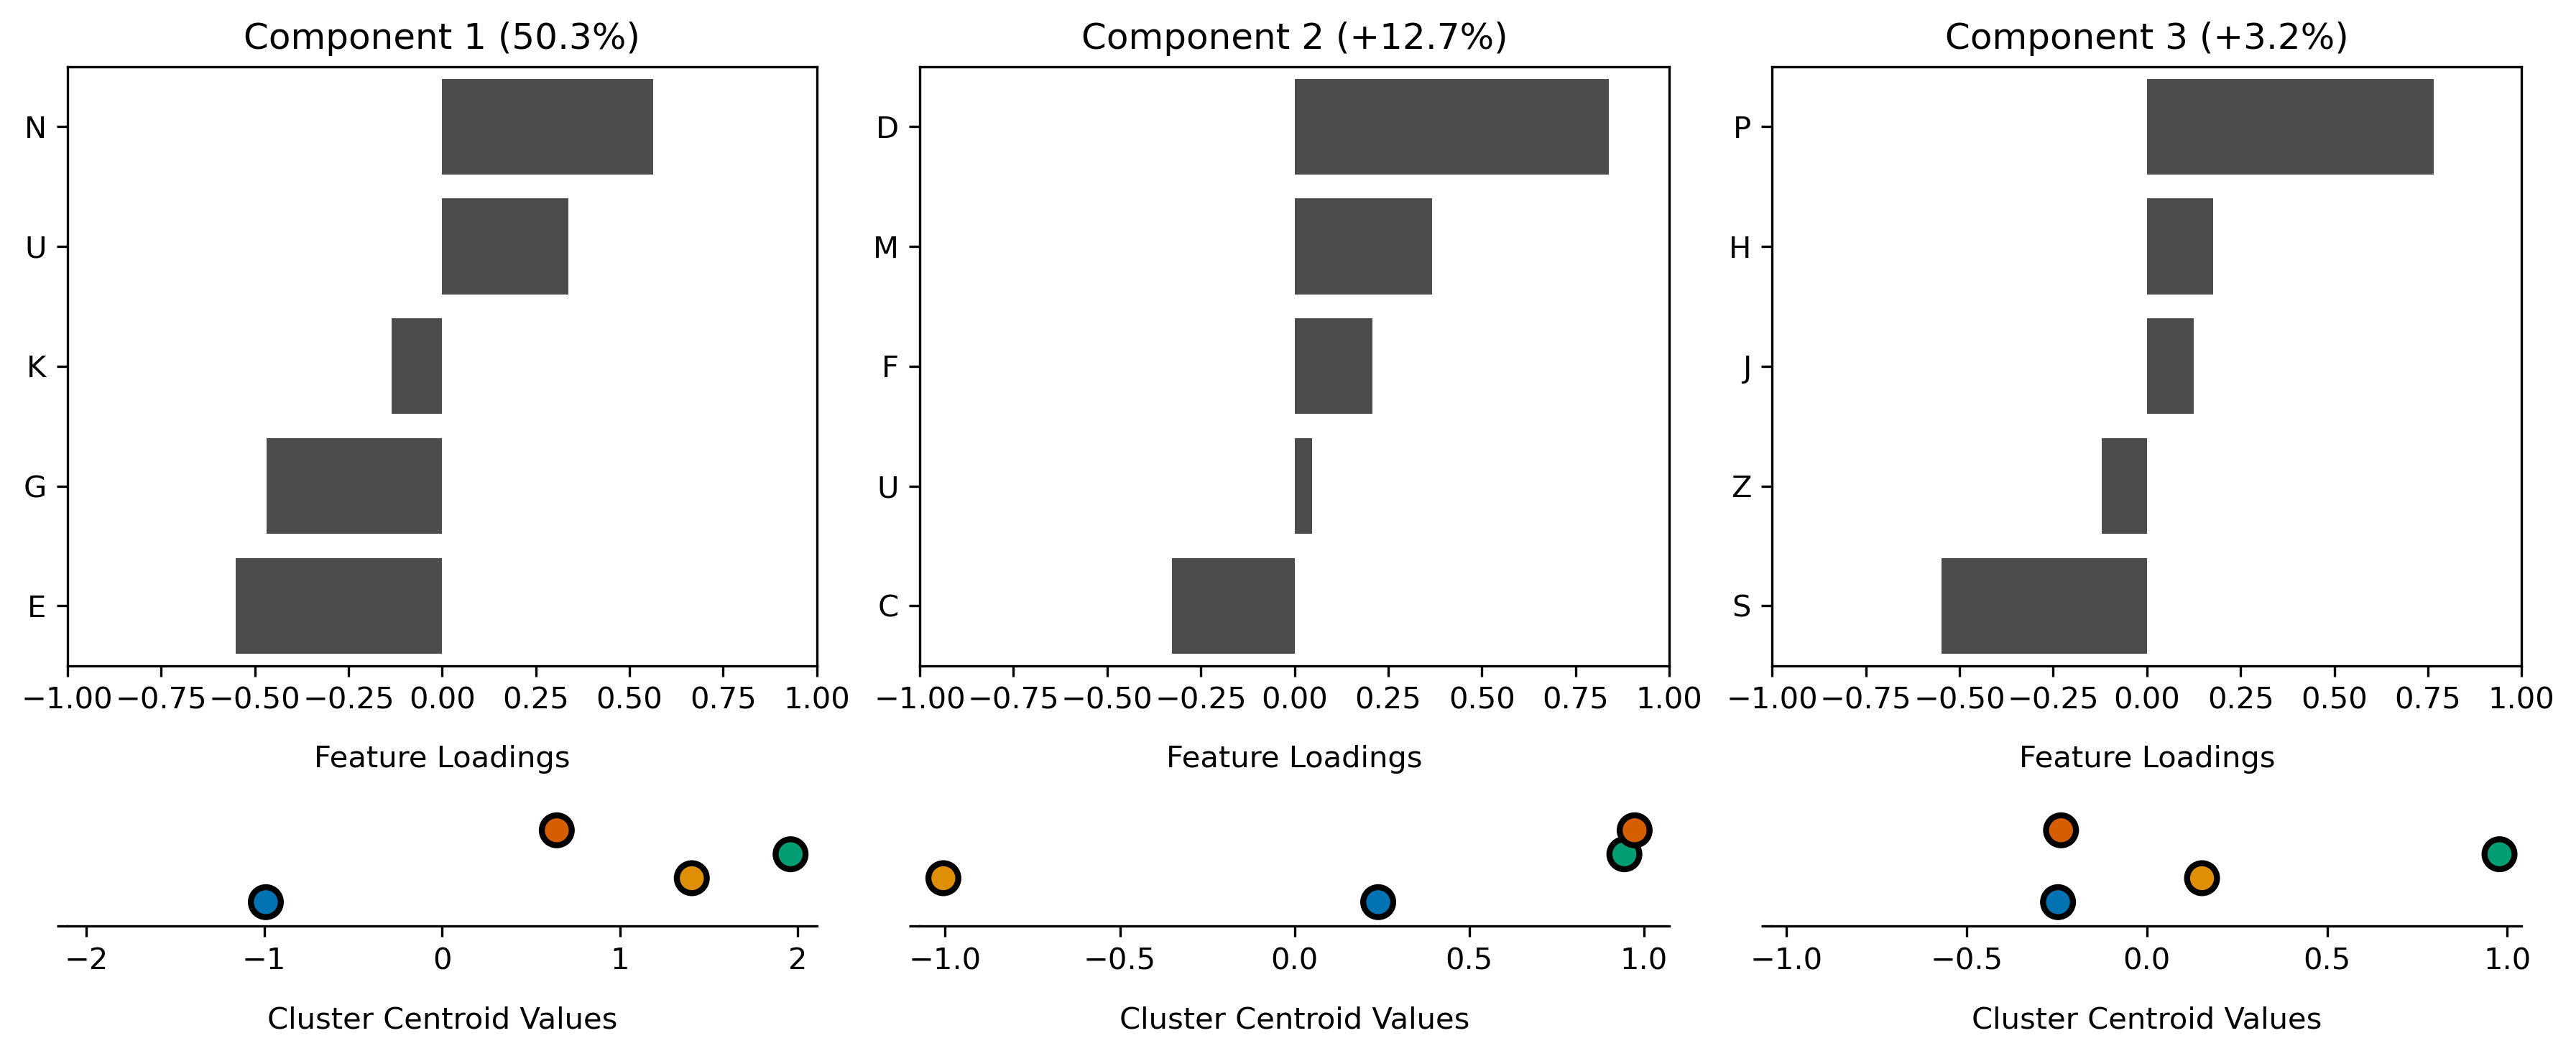

In [38]:
# Format loadings for plotting
loadings_subset = loadings.replace(to_replace= 0, value= np.nan)

# Format centroids for plotting
centroids_plot = centroids.copy()
centroids_plot['y'] = list('0' * len(centroids_plot))

# Make overall plot
fig, axes = plt.subplots(ncols=3, nrows=2, figsize= (12,5), dpi= 300, gridspec_kw= {'height_ratios': [5,1]})


# Plot component 1 loadings
c1 = sns.barplot(data= loadings_subset['comp.1'].dropna().sort_values(ascending= 0), orient= 'h', ax= axes[0][0], color= 'k', alpha= 0.7)
c1.set_xlabel('Feature Loadings', labelpad= 10)
c1.set_title('Component 1 (50.3%)')
c1.set_xlim((-1,1))
# Add component 1 values for cluster centroids
c1c = sns.scatterplot(centroids_plot, x= 'comp.1', y= 'Cluster', hue= 'Cluster', palette= colours,
                legend= False, s= 100, edgecolor= 'black', linewidth= 2, ax= axes[1][0])
# Format cluster centroids plot
c1c.set_ylim((0,5))
c1c.set_ylabel('')
c1c.set_yticks([0])
c1c.set_yticklabels('')
max_value = c1c.get_xlim()[-1]
c1c.set_xlim(0 - max_value, 0 + max_value)
c1c.set_xlabel('Cluster Centroid Values', labelpad= 10)
sns.despine(ax= c1c, left= True)



# Plot component 2 loadings
c2 = sns.barplot(data= loadings_subset['comp.2'].dropna().sort_values(ascending= 0), orient= 'h', ax= axes[0][1], color= 'k', alpha= 0.7)
c2.set_xlabel('Feature Loadings', labelpad= 10)
c2.set_title('Component 2 (+12.7%)')
c2.set_xlim((-1,1))
# Add component 2 values for cluster centroids
c2c = sns.scatterplot(centroids_plot, x= 'comp.2', y= 'Cluster', hue= 'Cluster', palette= colours,
                legend= False, s= 100, edgecolor= 'black', linewidth= 2, ax= axes[1][1])
# Format cluster centroids plot
c2c.set_ylim((0,5))
c2c.set_ylabel(None)
c2c.set_yticks([0])
c2c.set_yticklabels('')
max_value = c2c.get_xlim()[-1]
c2c.set_xlim(0 - max_value, 0 + max_value)
c2c.set_xlabel('Cluster Centroid Values', labelpad= 10)
sns.despine(ax= c2c, left= True)



# Plot component 3 loadings
c3 = sns.barplot(data= loadings_subset['comp.3'].dropna().sort_values(ascending= 0), orient= 'h', ax= axes[0][2], color= 'k', alpha= 0.7)
c3.set_xlabel('Feature Loadings', labelpad= 10)
c3.set_title('Component 3 (+3.2%)')
c3.set_xlim((-1,1))
# Add component 3 values for cluster centroids
c3c = sns.scatterplot(centroids_plot, x= 'comp.3', y= 'Cluster', hue= 'Cluster', palette= colours,
                legend= False, s= 100, edgecolor= 'black', linewidth= 2, ax= axes[1][2])
# Format cluster centroids plot
c3c.set_ylim((0,5))
c3c.set_ylabel('')
c3c.set_yticks([0])
c3c.set_yticklabels('')
max_value = c3c.get_xlim()[-1]
c3c.set_xlim(0 - max_value, 0 + max_value)
c3c.set_xlabel('Cluster Centroid Values', labelpad= 10)
sns.despine(ax= c3c, left= True)

# Tidy up 
plt.tight_layout()

# Export to file
plt.savefig("Figures/sPLS-DA_feature_loadings_and_cluster_centroid_values.png")

#### Plot features picked out by sPLS-DA

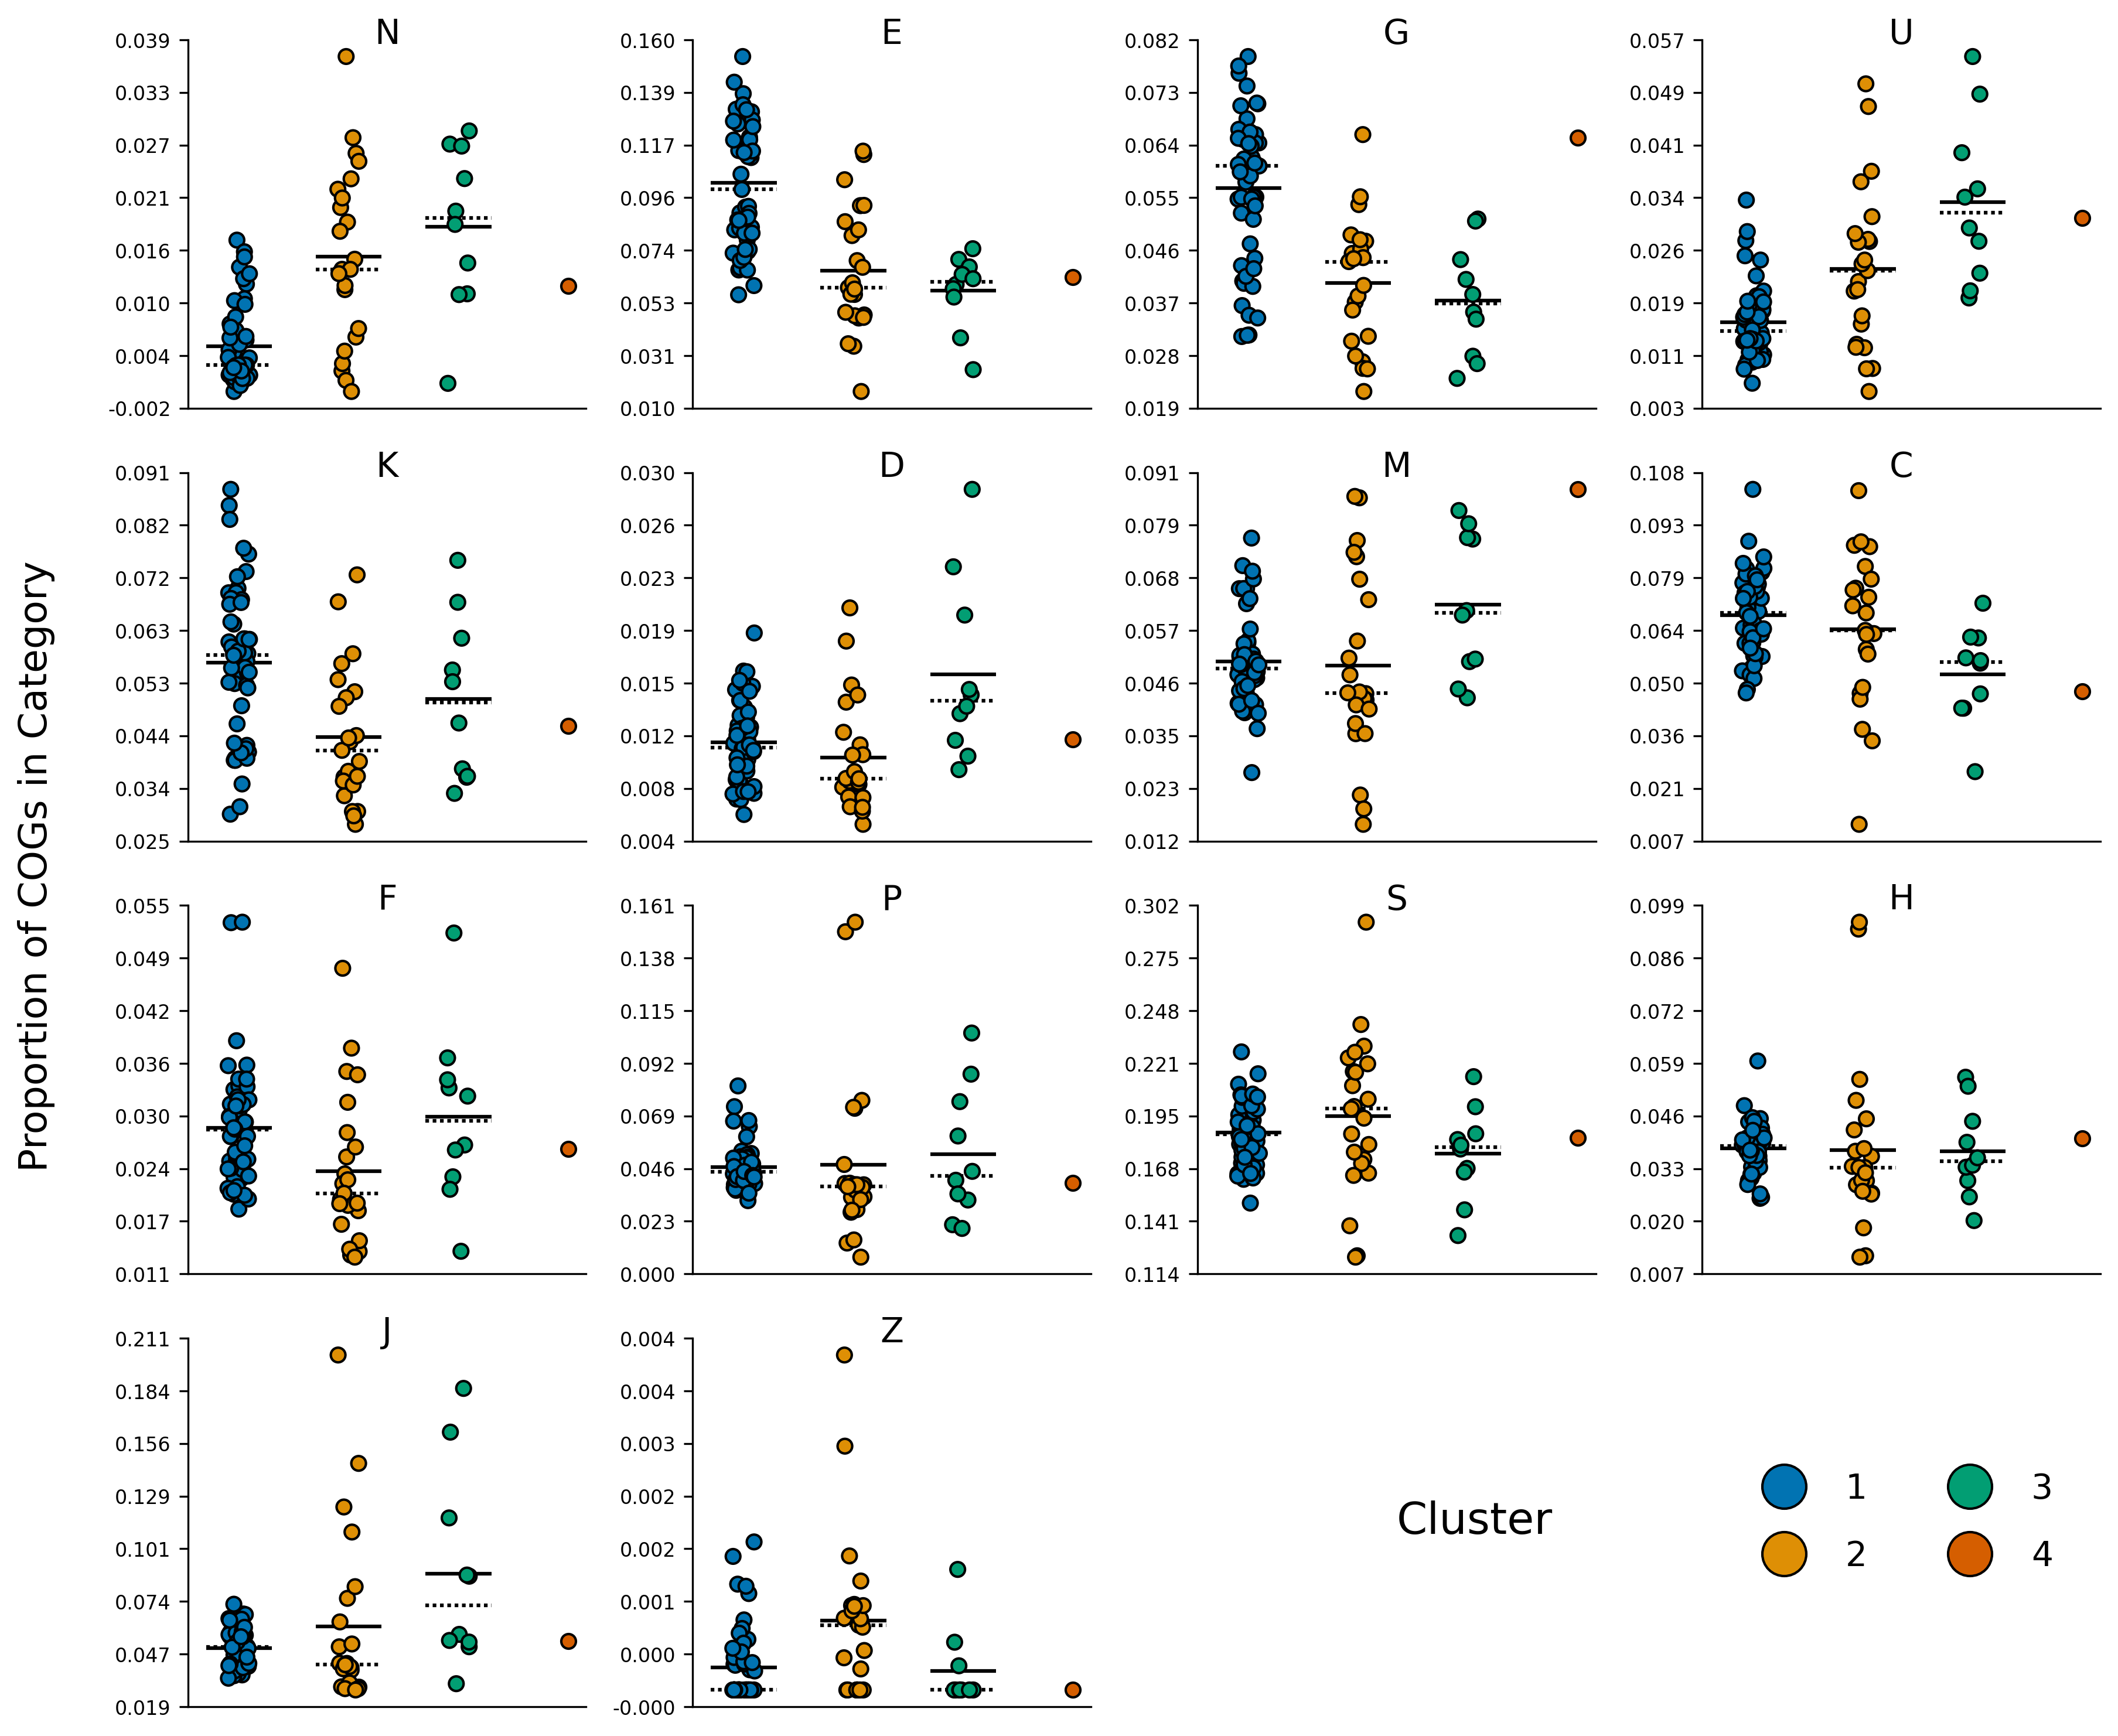

In [39]:
# Make figure
fig, axes = plt.subplots(ncols= 4, nrows= 4, figsize= (12,10), dpi= 300)
axes = axes.flatten()

# Custom formatter: 2 decimal places
formatter = FuncFormatter(lambda val, _: f"{val:.3f}")

# Plot
for i, category in enumerate(selected_features):
    
    p = sns.stripplot(data= COG, x='Cluster', y= category, jitter= True, palette= colours, hue= 'Cluster',
                  native_scale= True, s= 6, alpha= 1, linewidth= 1, edgecolor= 'black', ax= axes[i],
                     legend= True)
    
    # Add cluster means and medians
    for cluster in COG['Cluster'].unique():
        if cluster != 4:
            # mean
            y= COG[COG['Cluster'] == cluster][category].mean()
            p.hlines(xmin= cluster-0.3, xmax= cluster+0.3, y= y, color= 'Black')
            # median
            y= COG[COG['Cluster'] == cluster][category].median()
            p.hlines(xmin= cluster-0.3, xmax= cluster+0.3, y= y, color= 'Black',linestyle= (0,(1,1)))
        
    # Tidy up
    p.set_title(category, fontsize= 14, y= 0.95)
    p.set_ylabel('')
    p.set_xlabel('')
    p.set_xticks(ticks= [])
    
    # Format y ticks
    ymin, ymax = axes[i].get_ylim() 
    yticks = np.linspace(ymin, ymax, 8)
    axes[i].set_yticks(ticks= yticks, labels= yticks, fontsize=8)
    axes[i].yaxis.set_major_formatter(formatter) # set 2 decimal places
        
        
# Get legend from one subplot
handles, labels = axes[0].get_legend_handles_labels()
        
# Remove legends from non-penultimate plots
for axis in axes[:-1]:
        if axis.has_data() == True:
            axis.legend_.remove()

# Hide final plots    
axes[-1].set_axis_off()
axes[-2].set_axis_off()

# Add legend to final plot
axes[-1].legend(handles, labels, loc= 'center', title= '', ncols= 2,
                frameon= False, fontsize= 14, title_fontsize= 16, labelspacing= 1,
               markerscale= 3)

# Add legend title to penultimate plot
axes[-2].text(x= 0.5, y= 0.47, s='Cluster', fontsize= 18)

# Hide empty plots
for axis in axes[:-2]:
    if axis.has_data() == False:    
        fig.delaxes(axis)

# Tidy up
fig.supylabel(t= 'Proportion of COGs in Category', x= 0, fontsize= 16)
sns.despine()
plt.tight_layout()

# Export to file
plt.savefig("Figures/COG_category_proportions_per_cluster.png")

# Permutation testing of sPLS-DA

In [40]:
i=0
permutation_accuracies = []

# Remove any previous output
!rm sPLS-DA/sPLS-DA_permutation_testing.txt

while i<1000:
    try:
        ro.r("""
        
        # Load in data
        data = read.csv("sPLS-DA/sPLS-DA_input.csv")
        
        # Remove only Cluster 4 MAG (interferes with train / test splits)
        data = subset(data, Cluster != 4)
        
        # Remove Cluster and Genomic bins columns
        Cluster = data$Cluster
        genomicBins = data$Genomic.bins
        data$Cluster = NULL
        data$Genomic.bins = NULL
        
        X = data
        y = sample(Cluster)
        
        # Train model
        trained_model = splsda(X,y, ncomp=3, scale= FALSE, max.iter=100, keepX= tuning$choice.keepX)
        
        performance <- perf(trained_model, validation = "Mfold", folds=5, progressBar = FALSE, nrepeat = 100, measure= "BER", dist= "centroids.dist")
        
        """)
        BER = ro.r("performance$error.rate$BER")
        classification_accuracy = np.round((1 - BER[-1]) *100,1)
        permutation_accuracies.append(classification_accuracy)
        i += 1
    except KeyboardInterrupt:
        i = 1000

with open("sPLS-DA/sPLS-DA_permutation_testing.txt",'w') as fl:
    for score in permutation_accuracies:
        fl.write(str(score) + '\n')

rm: cannot remove 'sPLS-DA/sPLS-DA_permutation_testing.txt': No such file or directory


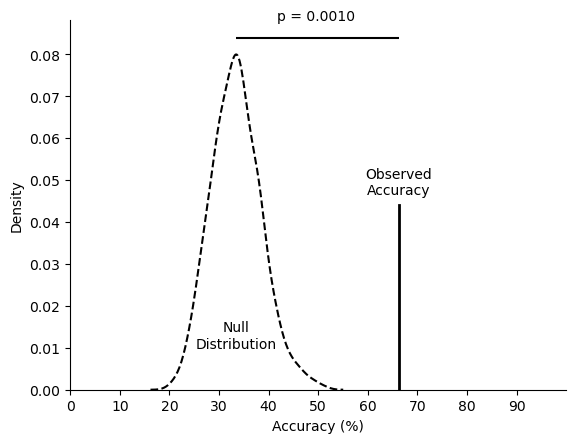

In [41]:
# Reimport accuracy data
with open('sPLS-DA/sPLS-DA_permutation_testing.txt', 'r') as fl:
    permutation_accuracies = fl.readlines()

# remove \n characters
permutation_accuracies = [float(accuracy.strip()) for accuracy in permutation_accuracies]

# Compute empirical p-value with +1 correction
count_extreme = np.sum(permutation_accuracies >= accuracy)
p_value = (count_extreme + 1) / (len(permutation_accuracies) + 1)

#print(f"Empirical p-value: {p_value:.4f}")

# Plot distribution of permuted accuracies
permutation_mean = np.mean(permutation_accuracies)
p = sns.kdeplot(permutation_accuracies, color= 'black', linestyle= 'dashed')
p.text(x= permutation_mean, y= 0.01, s= 'Null\nDistribution', horizontalalignment= 'center')

# Add observed accuracy
p.axvline(x= accuracy, color= 'black', ymax= 0.5, linewidth=2)
p.text(x= accuracy, y= (1/1.8)*p.get_ylim()[-1], s= 'Observed\nAccuracy', horizontalalignment= 'center')

# Add p value
p.hlines(y= p.get_ylim()[-1], xmin= permutation_mean, xmax= accuracy, color= 'black')
position = accuracy - permutation_mean / 2
p.text(x= position, y= p.get_ylim()[-1], s= f"p = {p_value:.4f}", horizontalalignment= 'center')

# Tidy up 
plt.xlabel('Accuracy (%)')
plt.xlim((0,100))
plt.xticks(np.arange(0,100,10));
sns.despine()

# Export to file
plt.savefig("Figures/sPLS-DA_accuracy_permutation_testing.png", dpi= 300)